# 6.2.3 ResNet18Transfer分阶段正式训练

本 Notebook 面向 AutoDL RTX 4090D 服务器环境，完成 ResNet18Transfer 的三阶段迁移学习：

1. **阶段 A：分类头预热**——冻结预训练主干，仅训练 EuroSAT 10 类分类头；
2. **阶段 B：深层特征微调**——解冻 Layer4 与分类头；
3. **阶段 C：全模型微调**——解冻全部网络参数，使用较小学习率联合优化。

训练过程中统一记录训练/验证损失、Top-1、Top-3、Macro-F1、学习率、耗时、显存峰值与检查点，并以验证集 Macro-F1 选择全局最佳模型。测试集不在本 Notebook 中使用。

In [1]:
# ==========================================
# 重启内核后的结果恢复检查
# ==========================================

from pathlib import Path
import pandas as pd
import torch


PROJECT_ROOT = Path(
    "/root/autodl-tmp/课设"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "resnet18_transfer"
)

RESULT_ROOT = (
    PROJECT_ROOT
    / "results"
    / "06_模型训练与优化"
)


BEST_MODEL_PATH = (
    MODEL_DIR
    / "resnet18_transfer_best_model.pth"
)


LAST_CHECKPOINT_PATH = (
    MODEL_DIR
    / "resnet18_transfer_last_checkpoint.pth"
)


print(
    "=" * 70
)

print(
    "ResNet18Transfer训练结果恢复检查"
)

print(
    "=" * 70
)


print(
    "\n最佳模型："
)

print(
    BEST_MODEL_PATH
)

print(
    "是否存在：",
    BEST_MODEL_PATH.is_file()
)


print(
    "\n最后检查点："
)

print(
    LAST_CHECKPOINT_PATH
)

print(
    "是否存在：",
    LAST_CHECKPOINT_PATH.is_file()
)


if not BEST_MODEL_PATH.is_file():

    raise FileNotFoundError(
        f"没有找到最佳模型：\n"
        f"{BEST_MODEL_PATH}"
    )


# ------------------------------------------
# 自动寻找训练历史CSV
# ------------------------------------------
history_candidates = []


if RESULT_ROOT.exists():

    for path in RESULT_ROOT.rglob(
        "*.csv"
    ):

        filename = path.name.lower()

        if (
            "训练历史" in path.name
            or "history" in filename
        ):

            history_candidates.append(
                path
            )


print(
    "\n找到的训练历史候选文件："
)


for path in history_candidates:

    print(
        path
    )


if len(
    history_candidates
) == 0:

    print(
        "\n提醒：没有自动找到训练历史CSV，"
        "但最佳模型权重已经成功保存，"
        "不会影响后续模型对比和测试。"
    )

    HISTORY_PATH = None
    history_df = None

else:

    HISTORY_PATH = sorted(
        history_candidates,
        key=lambda path: path.stat().st_mtime,
        reverse=True
    )[0]


    history_df = pd.read_csv(
        HISTORY_PATH,
        encoding="utf-8-sig"
    )


    print(
        f"\n采用训练历史：\n"
        f"{HISTORY_PATH}"
    )

    print(
        f"训练记录轮数："
        f"{len(history_df)}"
    )


# ------------------------------------------
# 检查最佳模型内容
# ------------------------------------------
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location="cpu",
    weights_only=False
)


if isinstance(
    checkpoint,
    dict
):

    print(
        "\n最佳模型文件读取成功。"
    )

    print(
        "顶层字段："
    )

    print(
        list(
            checkpoint.keys()
        )[:20]
    )

else:

    print(
        "\n最佳模型文件读取成功，"
        "内容为直接state_dict格式。"
    )


print(
    "\n恢复检查完成。"
)

print(
    "不要重新运行正式训练Cell。"
)

ResNet18Transfer训练结果恢复检查

最佳模型：
/root/autodl-tmp/课设/models/resnet18_transfer/resnet18_transfer_best_model.pth
是否存在： True

最后检查点：
/root/autodl-tmp/课设/models/resnet18_transfer/resnet18_transfer_last_checkpoint.pth
是否存在： True

找到的训练历史候选文件：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.2_BaselineCNN正式训练/05_BaselineCNN正式训练历史.csv
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.2_BaselineCNN正式训练/07_BaselineCNN训练历史.csv
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.3_ResNet18Transfer分阶段正式训练/07_ResNet18Transfer训练历史.csv

采用训练历史：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.3_ResNet18Transfer分阶段正式训练/07_ResNet18Transfer训练历史.csv
训练记录轮数：30

最佳模型文件读取成功。
顶层字段：
['model_state_dict', 'model_name', 'phase_key', 'phase_name', 'best_global_epoch', 'best_validation_metrics', 'best_global', 'run_config', 'phase_configs', 'class_names_en', 'class_names_cn', 'saved_at']

恢复检查完成。
不要重新运行正式训练Cell。


In [2]:
# ==========================================
# Cell 2：运行环境、中文字体与随机性控制
# ==========================================

import os

# 避免部分科学计算库重复加载 OpenMP 时导致内核退出
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import json
import math
import time
import random
import platform
import subprocess
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.font_manager import FontProperties

from IPython.display import display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import clip_grad_norm_

import torchvision
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix
)

from tqdm import tqdm


warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module="PIL"
)


# --------------------------------------------------
# 1. 中文字体配置
# --------------------------------------------------
def find_chinese_font_file():
    preferred_paths = [
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
        "/usr/share/fonts/truetype/wqy/wqy-microhei.ttc",
        "/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc",
        "/usr/share/fonts/truetype/arphic/uming.ttc",
        "/usr/share/fonts/truetype/arphic/ukai.ttc"
    ]

    for font_path in preferred_paths:
        font_path = Path(font_path)

        if font_path.is_file():
            return font_path

    search_directories = [
        Path("/usr/share/fonts"),
        Path("/usr/local/share/fonts"),
        Path.home() / ".fonts"
    ]

    font_keywords = [
        "notosanscjk",
        "sourcehan",
        "wqy",
        "microhei",
        "zenhei",
        "simhei",
        "yahei",
        "uming",
        "ukai"
    ]

    for directory in search_directories:
        if not directory.exists():
            continue

        for font_path in directory.rglob("*"):
            if (
                font_path.is_file()
                and font_path.suffix.lower()
                in {".ttf", ".otf", ".ttc"}
            ):
                lower_name = font_path.name.lower()

                if any(
                    keyword in lower_name
                    for keyword in font_keywords
                ):
                    return font_path

    return None


def refresh_matplotlib_font_cache():
    cache_directory = Path(
        matplotlib.get_cachedir()
    )

    for cache_file in cache_directory.glob(
        "fontlist-v*.json"
    ):
        try:
            cache_file.unlink()
        except OSError:
            pass

    font_manager._load_fontmanager(
        try_read_cache=False
    )


CHINESE_FONT_PATH = find_chinese_font_file()

if (
    CHINESE_FONT_PATH is None
    and hasattr(os, "geteuid")
    and os.geteuid() == 0
):
    print(
        "未检测到中文字体，尝试安装 fonts-noto-cjk……"
    )

    subprocess.run(
        [
            "apt-get",
            "update",
            "-qq"
        ],
        check=False
    )

    subprocess.run(
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "fonts-noto-cjk"
        ],
        check=False
    )

    subprocess.run(
        [
            "fc-cache",
            "-f"
        ],
        check=False
    )

    refresh_matplotlib_font_cache()
    CHINESE_FONT_PATH = find_chinese_font_file()


if CHINESE_FONT_PATH is None:
    raise RuntimeError(
        "没有找到可用中文字体。请在终端执行：\n"
        "apt-get update -qq && "
        "apt-get install -y fonts-noto-cjk"
    )


font_manager.fontManager.addfont(
    str(CHINESE_FONT_PATH)
)

CHINESE_FONT_PROPERTY = FontProperties(
    fname=str(CHINESE_FONT_PATH)
)

CHINESE_FONT_NAME = (
    CHINESE_FONT_PROPERTY.get_name()
)

plt.rcParams["font.family"] = CHINESE_FONT_NAME
plt.rcParams["font.sans-serif"] = [
    CHINESE_FONT_NAME
]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300


# --------------------------------------------------
# 2. 固定随机性
# --------------------------------------------------
SEED = 42


def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_global_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

torch.use_deterministic_algorithms(
    True,
    warn_only=True
)

torch.set_float32_matmul_precision(
    "high"
)


# --------------------------------------------------
# 3. 设备检查
# --------------------------------------------------
DEVICE = torch.device(
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "当前 Notebook 为 AutoDL GPU 正式训练版本，"
        "但没有检测到 CUDA。请确认实例已经开机且选择 GPU 内核。"
    )


GPU_NAME = torch.cuda.get_device_name(0)
GPU_MEMORY_GB = (
    torch.cuda.get_device_properties(0)
    .total_memory
    / 1024 ** 3
)

print("AutoDL GPU环境检查成功。")
print(f"当前设备：{DEVICE}")
print(f"GPU型号：{GPU_NAME}")
print(f"GPU显存：{GPU_MEMORY_GB:.2f} GB")
print(f"Python版本：{platform.python_version()}")
print(f"PyTorch版本：{torch.__version__}")
print(f"Torchvision版本：{torchvision.__version__}")
print(f"PyTorch CUDA版本：{torch.version.cuda}")
print(f"cuDNN版本：{torch.backends.cudnn.version()}")
print(f"中文字体：{CHINESE_FONT_NAME}")
print(f"随机种子：{SEED}")

AutoDL GPU环境检查成功。
当前设备：cuda:0
GPU型号：NVIDIA GeForce RTX 4090 D
GPU显存：23.52 GB
Python版本：3.12.3
PyTorch版本：2.5.1+cu124
Torchvision版本：0.20.1+cu124
PyTorch CUDA版本：12.4
cuDNN版本：90100
中文字体：Noto Sans CJK JP
随机种子：42


In [3]:
# ==========================================
# Cell 3：项目路径与统一训练配置
# ==========================================

PROJECT_ROOT = Path(
    "/root/autodl-tmp/课设"
)

if not PROJECT_ROOT.is_dir():
    raise FileNotFoundError(
        f"项目根目录不存在：\n{PROJECT_ROOT}"
    )


DATASET_DIR = (
    PROJECT_ROOT
    / "EuroSAT_RGB"
)

SPLIT_RESULT_DIR = (
    PROJECT_ROOT
    / "results"
    / "4.3.1_数据集分层划分"
)

TRAIN_MANIFEST_PATH = (
    SPLIT_RESULT_DIR
    / "03_训练集样本清单.csv"
)

VAL_MANIFEST_PATH = (
    SPLIT_RESULT_DIR
    / "04_验证集样本清单.csv"
)

TEST_MANIFEST_PATH = (
    SPLIT_RESULT_DIR
    / "05_测试集样本清单.csv"
)


RESULT_DIR = (
    PROJECT_ROOT
    / "results"
    / "06_模型训练与优化"
    / "6.2.3_ResNet18Transfer分阶段正式训练"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "resnet18_transfer"
)

PRETRAINED_DIR = (
    PROJECT_ROOT
    / "models"
    / "pretrained"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PRETRAINED_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# --------------------------------------------------
# 1. 类别信息
# --------------------------------------------------
CLASS_NAMES_EN = [
    "AnnualCrop",
    "PermanentCrop",
    "Forest",
    "HerbaceousVegetation",
    "Pasture",
    "Highway",
    "Industrial",
    "Residential",
    "River",
    "SeaLake"
]

CLASS_NAMES_CN = [
    "年生作物地",
    "永久性作物地",
    "森林",
    "草本植被",
    "牧场",
    "高速公路",
    "工业区",
    "居民区",
    "河流",
    "海洋与湖泊"
]

CLASS_TO_INDEX = {
    class_name: class_index
    for class_index, class_name
    in enumerate(CLASS_NAMES_EN)
}

CLASS_CN_TO_INDEX = {
    class_name: class_index
    for class_index, class_name
    in enumerate(CLASS_NAMES_CN)
}

INDEX_TO_CLASS_EN = {
    class_index: class_name
    for class_name, class_index
    in CLASS_TO_INDEX.items()
}

INDEX_TO_CLASS_CN = {
    class_index: class_name
    for class_index, class_name
    in enumerate(CLASS_NAMES_CN)
}


# --------------------------------------------------
# 2. 服务器训练配置
# --------------------------------------------------
IMAGE_SIZE = 224
NUM_CLASSES = 10

BATCH_SIZE = 32
NUM_WORKERS = 8
PIN_MEMORY = True
PERSISTENT_WORKERS = True
PREFETCH_FACTOR = 2

USE_AMP = True
MAX_GRAD_NORM = 1.0
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.0

SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 2
SCHEDULER_THRESHOLD = 1e-4

DROPOUT_RATE = 0.30

# False：检测到上次检查点时继续训练；
# True：删除本节训练状态后从头重新训练。
FORCE_RETRAIN = False

# 断线或内核重启后，是否自动从 last_checkpoint 继续
RESUME_IF_AVAILABLE = True


RUN_CONFIG = {
    "project_root": str(PROJECT_ROOT),
    "dataset_dir": str(DATASET_DIR),
    "result_dir": str(RESULT_DIR),
    "model_dir": str(MODEL_DIR),
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "num_classes": NUM_CLASSES,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "persistent_workers": PERSISTENT_WORKERS,
    "prefetch_factor": PREFETCH_FACTOR,
    "use_amp": USE_AMP,
    "max_grad_norm": MAX_GRAD_NORM,
    "weight_decay": WEIGHT_DECAY,
    "label_smoothing": LABEL_SMOOTHING,
    "scheduler_factor": SCHEDULER_FACTOR,
    "scheduler_patience": SCHEDULER_PATIENCE,
    "scheduler_threshold": SCHEDULER_THRESHOLD,
    "dropout_rate": DROPOUT_RATE,
    "device": str(DEVICE),
    "gpu_name": GPU_NAME,
    "pytorch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
    "created_at": datetime.now().isoformat(
        timespec="seconds"
    )
}


CONFIG_PATH = (
    RESULT_DIR
    / "00_ResNet18Transfer正式训练配置.json"
)

with open(
    CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        RUN_CONFIG,
        file,
        ensure_ascii=False,
        indent=2
    )


config_display_df = pd.DataFrame(
    [
        ["设备", str(DEVICE)],
        ["GPU", GPU_NAME],
        ["输入尺寸", f"3×{IMAGE_SIZE}×{IMAGE_SIZE}"],
        ["批次大小", BATCH_SIZE],
        ["DataLoader进程", NUM_WORKERS],
        ["混合精度", USE_AMP],
        ["梯度裁剪", MAX_GRAD_NORM],
        ["权重衰减", WEIGHT_DECAY],
        ["分类头Dropout", DROPOUT_RATE],
        ["结果目录", str(RESULT_DIR)],
        ["模型目录", str(MODEL_DIR)]
    ],
    columns=[
        "配置项",
        "配置值"
    ]
)

display(config_display_df)
print(f"训练配置已保存：{CONFIG_PATH}")

,配置项,配置值
0,设备,cuda:0
1,GPU,NVIDIA GeForce RTX 4090 D
2,输入尺寸,3×224×224
3,批次大小,32
4,DataLoader进程,8
5,混合精度,True
6,梯度裁剪,1.0
7,权重衰减,0.0001
8,分类头Dropout,0.3
9,结果目录,/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.3_R...


训练配置已保存：/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.3_ResNet18Transfer分阶段正式训练/00_ResNet18Transfer正式训练配置.json


In [4]:
# ==========================================
# Cell 4：读取并验证训练集、验证集清单
# ==========================================

EXPECTED_TRAIN_COUNT = 18900
EXPECTED_VAL_COUNT = 4050


def detect_column(
    dataframe,
    candidates
):
    for candidate in candidates:
        if candidate in dataframe.columns:
            return candidate

    return None


def read_manifest_csv(
    csv_path
):
    csv_path = Path(csv_path)

    if not csv_path.is_file():
        raise FileNotFoundError(
            f"清单文件不存在：\n{csv_path}"
        )

    dataframe = pd.read_csv(
        csv_path,
        encoding="utf-8-sig",
        low_memory=False
    )

    dataframe.columns = [
        str(column)
        .replace("\ufeff", "")
        .replace("\r", "")
        .replace("\n", "")
        .strip()
        for column in dataframe.columns
    ]

    return dataframe


def resolve_image_path(
    raw_path,
    class_name=None
):
    normalized_path = (
        str(raw_path)
        .strip()
        .replace("\\", "/")
    )

    raw_candidate = Path(
        normalized_path
    )

    candidate_paths = []

    if raw_candidate.is_absolute():
        candidate_paths.append(
            raw_candidate
        )

    candidate_paths.extend(
        [
            PROJECT_ROOT / normalized_path,
            DATASET_DIR / normalized_path,
            DATASET_DIR / "data" / normalized_path
        ]
    )

    lower_path = normalized_path.lower()

    eurosat_marker = "eurosat_rgb/"

    if eurosat_marker in lower_path:
        marker_index = lower_path.index(
            eurosat_marker
        )

        eurosat_relative = normalized_path[
            marker_index:
        ]

        candidate_paths.append(
            PROJECT_ROOT
            / eurosat_relative
        )

    data_marker = "data/"

    if data_marker in lower_path:
        data_index = lower_path.index(
            data_marker
        )

        data_relative = normalized_path[
            data_index:
        ]

        candidate_paths.append(
            DATASET_DIR
            / data_relative
        )

    if class_name is not None:
        file_name = Path(
            normalized_path
        ).name

        candidate_paths.extend(
            [
                DATASET_DIR
                / "data"
                / str(class_name)
                / file_name,

                DATASET_DIR
                / str(class_name)
                / file_name
            ]
        )

    unique_candidates = []

    for candidate_path in candidate_paths:
        candidate_path = Path(
            candidate_path
        )

        if candidate_path not in unique_candidates:
            unique_candidates.append(
                candidate_path
            )

    for candidate_path in unique_candidates:
        if candidate_path.is_file():
            return str(
                candidate_path.resolve()
            )

    return str(
        unique_candidates[0]
        if unique_candidates
        else raw_candidate
    )


def standardize_manifest(
    raw_dataframe,
    subset_name
):
    dataframe = (
        raw_dataframe
        .copy()
        .reset_index(drop=True)
    )

    path_column = detect_column(
        dataframe,
        [
            "完整图像路径",
            "相对路径",
            "图像路径",
            "文件路径",
            "绝对路径",
            "路径",
            "image_path",
            "file_path",
            "filepath",
            "path"
        ]
    )

    class_en_column = detect_column(
        dataframe,
        [
            "类别英文名称",
            "英文类别名称",
            "class_name",
            "class"
        ]
    )

    class_cn_column = detect_column(
        dataframe,
        [
            "类别中文名称",
            "中文类别名称"
        ]
    )

    label_column = detect_column(
        dataframe,
        [
            "类别索引",
            "类别编号",
            "标签索引",
            "标签编号",
            "标签",
            "class_index",
            "label",
            "target"
        ]
    )

    if path_column is None:
        raise KeyError(
            f"{subset_name}没有找到路径字段。\n"
            f"实际字段：{dataframe.columns.tolist()}"
        )

    standardized_df = pd.DataFrame()

    standardized_df["原始路径"] = (
        dataframe[path_column]
        .astype(str)
        .str.strip()
    )

    if class_en_column is not None:
        standardized_df[
            "类别英文名称"
        ] = (
            dataframe[class_en_column]
            .astype(str)
            .str.strip()
        )

    if class_cn_column is not None:
        standardized_df[
            "类别中文名称"
        ] = (
            dataframe[class_cn_column]
            .astype(str)
            .str.strip()
        )

    if label_column is not None:
        standardized_df[
            "类别索引"
        ] = pd.to_numeric(
            dataframe[label_column],
            errors="coerce"
        )

    # 优先用英文类别名称映射标签，避免外部清单编号方式不同
    if "类别英文名称" in standardized_df.columns:
        mapped_labels = (
            standardized_df[
                "类别英文名称"
            ]
            .map(CLASS_TO_INDEX)
        )

        if not mapped_labels.isna().any():
            standardized_df[
                "类别索引"
            ] = mapped_labels

    elif "类别中文名称" in standardized_df.columns:
        mapped_labels = (
            standardized_df[
                "类别中文名称"
            ]
            .map(CLASS_CN_TO_INDEX)
        )

        if not mapped_labels.isna().any():
            standardized_df[
                "类别索引"
            ] = mapped_labels

    if "类别索引" not in standardized_df.columns:
        raise KeyError(
            f"{subset_name}没有找到可用标签字段。"
        )

    if standardized_df[
        "类别索引"
    ].isna().any():
        raise ValueError(
            f"{subset_name}存在无法识别的类别标签。"
        )

    standardized_df[
        "类别索引"
    ] = standardized_df[
        "类别索引"
    ].astype(int)

    unique_labels = sorted(
        standardized_df[
            "类别索引"
        ].unique().tolist()
    )

    # 兼容1～10编号
    if unique_labels == list(
        range(1, NUM_CLASSES + 1)
    ):
        standardized_df[
            "类别索引"
        ] = (
            standardized_df[
                "类别索引"
            ]
            - 1
        )

    if "类别英文名称" not in standardized_df.columns:
        standardized_df[
            "类别英文名称"
        ] = (
            standardized_df[
                "类别索引"
            ]
            .map(INDEX_TO_CLASS_EN)
        )

    if "类别中文名称" not in standardized_df.columns:
        standardized_df[
            "类别中文名称"
        ] = (
            standardized_df[
                "类别索引"
            ]
            .map(INDEX_TO_CLASS_CN)
        )

    standardized_df[
        "完整图像路径"
    ] = [
        resolve_image_path(
            raw_path,
            class_name
        )
        for raw_path, class_name
        in zip(
            standardized_df[
                "原始路径"
            ],
            standardized_df[
                "类别英文名称"
            ]
        )
    ]

    standardized_df[
        "数据子集"
    ] = subset_name

    return standardized_df


train_raw_df = read_manifest_csv(
    TRAIN_MANIFEST_PATH
)

val_raw_df = read_manifest_csv(
    VAL_MANIFEST_PATH
)

train_manifest_df = standardize_manifest(
    train_raw_df,
    "训练集"
)

val_manifest_df = standardize_manifest(
    val_raw_df,
    "验证集"
)


# --------------------------------------------------
# 完整性检查
# --------------------------------------------------
assert len(
    train_manifest_df
) == EXPECTED_TRAIN_COUNT, (
    f"训练集数量错误："
    f"{len(train_manifest_df):,}"
)

assert len(
    val_manifest_df
) == EXPECTED_VAL_COUNT, (
    f"验证集数量错误："
    f"{len(val_manifest_df):,}"
)

expected_labels = set(
    range(NUM_CLASSES)
)

assert set(
    train_manifest_df[
        "类别索引"
    ].unique()
) == expected_labels

assert set(
    val_manifest_df[
        "类别索引"
    ].unique()
) == expected_labels


train_duplicate_count = int(
    train_manifest_df[
        "完整图像路径"
    ].duplicated().sum()
)

val_duplicate_count = int(
    val_manifest_df[
        "完整图像路径"
    ].duplicated().sum()
)

train_val_overlap = (
    set(
        train_manifest_df[
            "完整图像路径"
        ]
    )
    & set(
        val_manifest_df[
            "完整图像路径"
        ]
    )
)

train_missing_count = int(
    (
        ~train_manifest_df[
            "完整图像路径"
        ].map(
            lambda path: Path(path).is_file()
        )
    ).sum()
)

val_missing_count = int(
    (
        ~val_manifest_df[
            "完整图像路径"
        ].map(
            lambda path: Path(path).is_file()
        )
    ).sum()
)


assert train_duplicate_count == 0
assert val_duplicate_count == 0
assert len(train_val_overlap) == 0
assert train_missing_count == 0, (
    f"训练集存在{train_missing_count}张缺失图像。"
)
assert val_missing_count == 0, (
    f"验证集存在{val_missing_count}张缺失图像。"
)


manifest_summary_df = pd.DataFrame(
    {
        "数据子集": [
            "训练集",
            "验证集"
        ],
        "样本数量": [
            len(train_manifest_df),
            len(val_manifest_df)
        ],
        "类别数量": [
            train_manifest_df[
                "类别索引"
            ].nunique(),
            val_manifest_df[
                "类别索引"
            ].nunique()
        ],
        "重复路径": [
            train_duplicate_count,
            val_duplicate_count
        ],
        "缺失图像": [
            train_missing_count,
            val_missing_count
        ]
    }
)

display(manifest_summary_df)


class_distribution_df = pd.DataFrame(
    {
        "类别索引": range(NUM_CLASSES),
        "类别中文名称": CLASS_NAMES_CN,
        "类别英文名称": CLASS_NAMES_EN,
        "训练集数量": [
            int(
                (
                    train_manifest_df[
                        "类别索引"
                    ]
                    == class_index
                ).sum()
            )
            for class_index
            in range(NUM_CLASSES)
        ],
        "验证集数量": [
            int(
                (
                    val_manifest_df[
                        "类别索引"
                    ]
                    == class_index
                ).sum()
            )
            for class_index
            in range(NUM_CLASSES)
        ]
    }
)

display(class_distribution_df)


train_standard_path = (
    RESULT_DIR
    / "01_训练集标准化清单.csv"
)

val_standard_path = (
    RESULT_DIR
    / "02_验证集标准化清单.csv"
)

class_distribution_path = (
    RESULT_DIR
    / "03_训练验证类别分布.csv"
)

train_manifest_df.to_csv(
    train_standard_path,
    index=False,
    encoding="utf-8-sig"
)

val_manifest_df.to_csv(
    val_standard_path,
    index=False,
    encoding="utf-8-sig"
)

class_distribution_df.to_csv(
    class_distribution_path,
    index=False,
    encoding="utf-8-sig"
)

print("训练集与验证集清单检查通过。")
print(f"训练集：{len(train_manifest_df):,}张")
print(f"验证集：{len(val_manifest_df):,}张")
print("训练集与验证集交集：0张")

,数据子集,样本数量,类别数量,重复路径,缺失图像
0,训练集,18900,10,0,0
1,验证集,4050,10,0,0


,类别索引,类别中文名称,类别英文名称,训练集数量,验证集数量
0,0,年生作物地,AnnualCrop,2100,450
1,1,永久性作物地,PermanentCrop,1750,375
2,2,森林,Forest,2100,450
3,3,草本植被,HerbaceousVegetation,2100,450
4,4,牧场,Pasture,1400,300
5,5,高速公路,Highway,1750,375
6,6,工业区,Industrial,1750,375
7,7,居民区,Residential,2100,450
8,8,河流,River,1750,375
9,9,海洋与湖泊,SeaLake,2100,450


训练集与验证集清单检查通过。
训练集：18,900张
验证集：4,050张
训练集与验证集交集：0张


In [5]:
# ==========================================
# Cell 5：图像变换、Dataset与DataLoader
# ==========================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


# 训练集：保持与前期数据增强方案一致
train_transform = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=InterpolationMode.BILINEAR,
            antialias=True
        ),

        transforms.RandomHorizontalFlip(
            p=0.50
        ),

        transforms.RandomVerticalFlip(
            p=0.50
        ),

        # 先反射填充再旋转，减少旋转后黑色边角
        transforms.Pad(
            padding=24,
            padding_mode="reflect"
        ),

        transforms.RandomRotation(
            degrees=15,
            interpolation=InterpolationMode.BILINEAR
        ),

        transforms.CenterCrop(
            IMAGE_SIZE
        ),

        transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.15,
            hue=0.03
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD
        )
    ]
)


# 验证集：只执行确定性尺寸调整与标准化
val_transform = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=InterpolationMode.BILINEAR,
            antialias=True
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD
        )
    ]
)


class ManifestImageDataset(Dataset):
    def __init__(
        self,
        manifest_df,
        transform=None
    ):
        self.manifest_df = (
            manifest_df
            .copy()
            .reset_index(drop=True)
        )

        self.transform = transform

    def __len__(self):
        return len(
            self.manifest_df
        )

    def __getitem__(
        self,
        index
    ):
        row = self.manifest_df.iloc[
            index
        ]

        image_path = row[
            "完整图像路径"
        ]

        label = int(
            row[
                "类别索引"
            ]
        )

        with Image.open(
            image_path
        ) as image_file:
            image = image_file.convert(
                "RGB"
            )

        if self.transform is not None:
            image = self.transform(
                image
            )

        return (
            image,
            label,
            image_path
        )


train_dataset = ManifestImageDataset(
    train_manifest_df,
    transform=train_transform
)

val_dataset = ManifestImageDataset(
    val_manifest_df,
    transform=val_transform
)


def seed_worker(
    worker_id
):
    worker_seed = (
        torch.initial_seed()
        % 2 ** 32
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


train_generator = torch.Generator()
train_generator.manual_seed(
    SEED
)


loader_common_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "worker_init_fn": seed_worker
}

if NUM_WORKERS > 0:
    loader_common_kwargs[
        "persistent_workers"
    ] = PERSISTENT_WORKERS

    loader_common_kwargs[
        "prefetch_factor"
    ] = PREFETCH_FACTOR


train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=train_generator,
    drop_last=False,
    **loader_common_kwargs
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    drop_last=False,
    **loader_common_kwargs
)


# --------------------------------------------------
# 单样本与验证批次检查
# --------------------------------------------------
sample_image, sample_label, sample_path = (
    train_dataset[0]
)

assert sample_image.shape == (
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
)

assert 0 <= sample_label < NUM_CLASSES


val_images, val_labels, val_paths = next(
    iter(
        val_loader
    )
)

assert val_images.shape[1:] == (
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
)

assert val_labels.min().item() >= 0
assert val_labels.max().item() < NUM_CLASSES


loader_summary_df = pd.DataFrame(
    [
        {
            "数据子集": "训练集",
            "样本数量": len(train_dataset),
            "批次数量": len(train_loader),
            "批次大小": BATCH_SIZE,
            "随机增强": "是",
            "随机打乱": "是"
        },
        {
            "数据子集": "验证集",
            "样本数量": len(val_dataset),
            "批次数量": len(val_loader),
            "批次大小": BATCH_SIZE,
            "随机增强": "否",
            "随机打乱": "否"
        }
    ]
)

display(loader_summary_df)

loader_summary_df.to_csv(
    RESULT_DIR
    / "04_DataLoader配置与规模.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Dataset与DataLoader检查通过。"
)

print(
    f"训练批次数：{len(train_loader)}"
)

print(
    f"验证批次数：{len(val_loader)}"
)

print(
    f"验证首批张量：{tuple(val_images.shape)}"
)

,数据子集,样本数量,批次数量,批次大小,随机增强,随机打乱
0,训练集,18900,591,32,是,是
1,验证集,4050,127,32,否,否


Dataset与DataLoader检查通过。
训练批次数：591
验证批次数：127
验证首批张量：(32, 3, 224, 224)


In [6]:
# ==========================================
# Cell 6：加载ImageNet预训练ResNet18并替换分类头
# ==========================================

PRETRAINED_WEIGHT_PATH = (
    PRETRAINED_DIR
    / "resnet18_imagenet1k_v1_state_dict.pth"
)


weights_enum = ResNet18_Weights.DEFAULT


if PRETRAINED_WEIGHT_PATH.is_file():
    print(
        "从项目缓存读取ImageNet预训练权重："
    )

    print(
        PRETRAINED_WEIGHT_PATH
    )

    pretrained_state_dict = torch.load(
        PRETRAINED_WEIGHT_PATH,
        map_location="cpu",
        weights_only=True
    )

else:
    print(
        "项目缓存中没有预训练权重，"
        "开始从PyTorch官方地址下载……"
    )

    try:
        pretrained_state_dict = (
            weights_enum.get_state_dict(
                progress=True,
                check_hash=True
            )
        )

    except Exception as error:
        raise RuntimeError(
            "ImageNet预训练权重下载失败。\n"
            "请确认服务器可以访问PyTorch模型地址，"
            "或将resnet18权重文件上传到：\n"
            f"{PRETRAINED_WEIGHT_PATH}"
        ) from error

    torch.save(
        pretrained_state_dict,
        PRETRAINED_WEIGHT_PATH
    )

    print(
        f"预训练权重已缓存："
        f"{PRETRAINED_WEIGHT_PATH}"
    )


model = resnet18(
    weights=None
)

load_result = model.load_state_dict(
    pretrained_state_dict,
    strict=True
)

assert len(
    load_result.missing_keys
) == 0

assert len(
    load_result.unexpected_keys
) == 0


classifier_input_features = (
    model.fc.in_features
)

model.fc = nn.Sequential(
    nn.Dropout(
        p=DROPOUT_RATE
    ),
    nn.Linear(
        classifier_input_features,
        NUM_CLASSES
    )
)


# 只对新分类层进行随机初始化
nn.init.xavier_uniform_(
    model.fc[1].weight
)

nn.init.zeros_(
    model.fc[1].bias
)


model = model.to(
    DEVICE
)


def count_parameters(
    target_model,
    trainable_only=False
):
    parameters = target_model.parameters()

    if trainable_only:
        parameters = [
            parameter
            for parameter
            in parameters
            if parameter.requires_grad
        ]

    return sum(
        parameter.numel()
        for parameter
        in parameters
    )


TOTAL_PARAMETERS = count_parameters(
    model,
    trainable_only=False
)

EXPECTED_TOTAL_PARAMETERS = 11181642

assert TOTAL_PARAMETERS == (
    EXPECTED_TOTAL_PARAMETERS
), (
    f"模型参数量与预期不一致："
    f"{TOTAL_PARAMETERS:,}"
)


# 前向传播结构检查
model.eval()

with torch.inference_mode():
    dummy_input = torch.zeros(
        2,
        3,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=DEVICE
    )

    dummy_output = model(
        dummy_input
    )

assert dummy_output.shape == (
    2,
    NUM_CLASSES
)


MODEL_STRUCTURE_PATH = (
    RESULT_DIR
    / "05_ResNet18Transfer模型结构.txt"
)

with open(
    MODEL_STRUCTURE_PATH,
    "w",
    encoding="utf-8"
) as file:
    file.write(
        str(model)
    )


model_summary_df = pd.DataFrame(
    [
        ["模型名称", "ResNet18Transfer"],
        ["预训练权重", "ImageNet-1K"],
        ["输入张量", f"3×{IMAGE_SIZE}×{IMAGE_SIZE}"],
        ["全局特征维度", classifier_input_features],
        ["分类类别数", NUM_CLASSES],
        ["分类头Dropout", DROPOUT_RATE],
        ["模型总参数", f"{TOTAL_PARAMETERS:,}"],
        ["前向输出", str(tuple(dummy_output.shape))]
    ],
    columns=[
        "项目",
        "结果"
    ]
)

display(model_summary_df)

print(
    "ResNet18Transfer构建成功。"
)

print(
    f"模型总参数：{TOTAL_PARAMETERS:,}"
)

print(
    f"前向输出形状：{tuple(dummy_output.shape)}"
)

从项目缓存读取ImageNet预训练权重：
/root/autodl-tmp/课设/models/pretrained/resnet18_imagenet1k_v1_state_dict.pth


,项目,结果
0,模型名称,ResNet18Transfer
1,预训练权重,ImageNet-1K
2,输入张量,3×224×224
3,全局特征维度,512
4,分类类别数,10
5,分类头Dropout,0.3
6,模型总参数,"11,181,642"
7,前向输出,"(2, 10)"


ResNet18Transfer构建成功。
模型总参数：11,181,642
前向输出形状：(2, 10)


In [7]:
# ==========================================
# Cell 7：训练、验证与指标计算函数
# ==========================================

def calculate_classification_metrics(
    y_true,
    y_pred
):
    y_true = np.asarray(
        y_true,
        dtype=np.int64
    )

    y_pred = np.asarray(
        y_pred,
        dtype=np.int64
    )

    labels = list(
        range(NUM_CLASSES)
    )

    macro_precision = precision_score(
        y_true,
        y_pred,
        labels=labels,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        labels=labels,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=labels,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        labels=labels,
        average="weighted",
        zero_division=0
    )

    return {
        "macro_precision": float(
            macro_precision
        ),
        "macro_recall": float(
            macro_recall
        ),
        "macro_f1": float(
            macro_f1
        ),
        "weighted_f1": float(
            weighted_f1
        )
    }


def set_trainable_phase(
    target_model,
    phase_key
):
    for parameter in target_model.parameters():
        parameter.requires_grad = False

    if phase_key == "A":
        for parameter in target_model.fc.parameters():
            parameter.requires_grad = True

    elif phase_key == "B":
        for parameter in target_model.layer4.parameters():
            parameter.requires_grad = True

        for parameter in target_model.fc.parameters():
            parameter.requires_grad = True

    elif phase_key == "C":
        for parameter in target_model.parameters():
            parameter.requires_grad = True

    else:
        raise ValueError(
            f"未知训练阶段：{phase_key}"
        )

    trainable_parameter_count = sum(
        parameter.numel()
        for parameter
        in target_model.parameters()
        if parameter.requires_grad
    )

    return trainable_parameter_count


def set_frozen_batchnorm_eval(
    target_model
):
    """
    冻结模块中的BatchNorm不仅停止梯度，
    同时停止运行均值与运行方差更新。
    """

    for module in target_model.modules():
        if isinstance(
            module,
            nn.BatchNorm2d
        ):
            module_parameters = list(
                module.parameters()
            )

            is_frozen = (
                len(module_parameters) > 0
                and not any(
                    parameter.requires_grad
                    for parameter
                    in module_parameters
                )
            )

            if is_frozen:
                module.eval()


def build_optimizer_and_scheduler(
    target_model,
    phase_config
):
    trainable_parameters = [
        parameter
        for parameter
        in target_model.parameters()
        if parameter.requires_grad
    ]

    if not trainable_parameters:
        raise RuntimeError(
            "当前阶段没有可训练参数。"
        )

    optimizer = torch.optim.AdamW(
        trainable_parameters,
        lr=phase_config[
            "initial_lr"
        ],
        weight_decay=WEIGHT_DECAY
    )

    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=SCHEDULER_FACTOR,
            patience=SCHEDULER_PATIENCE,
            threshold=SCHEDULER_THRESHOLD,
            threshold_mode="abs",
            min_lr=phase_config[
                "min_lr"
            ]
        )
    )

    return optimizer, scheduler


def create_grad_scaler():
    try:
        return torch.amp.GradScaler(
            "cuda",
            enabled=USE_AMP
        )

    except (TypeError, AttributeError):
        return torch.cuda.amp.GradScaler(
            enabled=USE_AMP
        )


def get_current_learning_rate(
    optimizer
):
    return max(
        parameter_group["lr"]
        for parameter_group
        in optimizer.param_groups
    )


def train_one_epoch(
    target_model,
    data_loader,
    criterion,
    optimizer,
    scaler,
    global_epoch,
    total_epochs
):
    target_model.train()
    set_frozen_batchnorm_eval(
        target_model
    )

    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats(
            DEVICE
        )

    running_loss = 0.0
    sample_count = 0
    top1_correct = 0
    top3_correct = 0

    all_true = []
    all_pred = []

    grad_norm_values = []

    progress_bar = tqdm(
        data_loader,
        desc=(
            f"Epoch {global_epoch}/{total_epochs} "
            "训练"
        ),
        leave=False
    )

    epoch_start_time = time.perf_counter()

    for images, labels, _ in progress_bar:
        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP
        ):
            logits = target_model(
                images
            )

            loss = criterion(
                logits,
                labels
            )

        scaler.scale(
            loss
        ).backward()

        scaler.unscale_(
            optimizer
        )

        trainable_parameters = [
            parameter
            for parameter
            in target_model.parameters()
            if (
                parameter.requires_grad
                and parameter.grad is not None
            )
        ]

        grad_norm = clip_grad_norm_(
            trainable_parameters,
            max_norm=MAX_GRAD_NORM
        )

        grad_norm_values.append(
            float(
                grad_norm.detach().cpu()
                if torch.is_tensor(grad_norm)
                else grad_norm
            )
        )

        scaler.step(
            optimizer
        )

        scaler.update()

        batch_size = labels.size(0)

        running_loss += (
            loss.item()
            * batch_size
        )

        sample_count += batch_size

        predictions = logits.argmax(
            dim=1
        )

        top1_correct += (
            predictions
            .eq(labels)
            .sum()
            .item()
        )

        top3_predictions = logits.topk(
            k=min(3, NUM_CLASSES),
            dim=1
        ).indices

        top3_correct += (
            top3_predictions
            .eq(
                labels.unsqueeze(1)
            )
            .any(dim=1)
            .sum()
            .item()
        )

        all_true.extend(
            labels.detach()
            .cpu()
            .tolist()
        )

        all_pred.extend(
            predictions.detach()
            .cpu()
            .tolist()
        )

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            grad=f"{grad_norm_values[-1]:.3f}",
            lr=(
                f"{get_current_learning_rate(optimizer):.2e}"
            )
        )

    epoch_seconds = (
        time.perf_counter()
        - epoch_start_time
    )

    classification_metrics = (
        calculate_classification_metrics(
            all_true,
            all_pred
        )
    )

    peak_memory_gb = 0.0

    if DEVICE.type == "cuda":
        peak_memory_gb = (
            torch.cuda.max_memory_allocated(
                DEVICE
            )
            / 1024 ** 3
        )

    return {
        "loss": float(
            running_loss
            / sample_count
        ),
        "top1": float(
            top1_correct
            / sample_count
        ),
        "top3": float(
            top3_correct
            / sample_count
        ),
        **classification_metrics,
        "epoch_seconds": float(
            epoch_seconds
        ),
        "peak_memory_gb": float(
            peak_memory_gb
        ),
        "mean_grad_norm": float(
            np.mean(
                grad_norm_values
            )
            if grad_norm_values
            else 0.0
        )
    }


@torch.inference_mode()
def evaluate_model(
    target_model,
    data_loader,
    criterion,
    return_outputs=False
):
    target_model.eval()

    running_loss = 0.0
    sample_count = 0
    top1_correct = 0
    top3_correct = 0

    all_true = []
    all_pred = []
    all_confidence = []
    all_paths = []

    progress_bar = tqdm(
        data_loader,
        desc="验证",
        leave=False
    )

    evaluation_start_time = (
        time.perf_counter()
    )

    for images, labels, paths in progress_bar:
        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP
        ):
            logits = target_model(
                images
            )

            loss = criterion(
                logits,
                labels
            )

        probabilities = torch.softmax(
            logits.float(),
            dim=1
        )

        confidence, predictions = (
            probabilities.max(
                dim=1
            )
        )

        top3_predictions = logits.topk(
            k=min(3, NUM_CLASSES),
            dim=1
        ).indices

        batch_size = labels.size(0)

        running_loss += (
            loss.item()
            * batch_size
        )

        sample_count += batch_size

        top1_correct += (
            predictions
            .eq(labels)
            .sum()
            .item()
        )

        top3_correct += (
            top3_predictions
            .eq(
                labels.unsqueeze(1)
            )
            .any(dim=1)
            .sum()
            .item()
        )

        all_true.extend(
            labels.detach()
            .cpu()
            .tolist()
        )

        all_pred.extend(
            predictions.detach()
            .cpu()
            .tolist()
        )

        all_confidence.extend(
            confidence.detach()
            .cpu()
            .tolist()
        )

        all_paths.extend(
            list(paths)
        )

    evaluation_seconds = (
        time.perf_counter()
        - evaluation_start_time
    )

    classification_metrics = (
        calculate_classification_metrics(
            all_true,
            all_pred
        )
    )

    result = {
        "loss": float(
            running_loss
            / sample_count
        ),
        "top1": float(
            top1_correct
            / sample_count
        ),
        "top3": float(
            top3_correct
            / sample_count
        ),
        **classification_metrics,
        "evaluation_seconds": float(
            evaluation_seconds
        )
    }

    if return_outputs:
        result.update(
            {
                "y_true": np.asarray(
                    all_true,
                    dtype=np.int64
                ),
                "y_pred": np.asarray(
                    all_pred,
                    dtype=np.int64
                ),
                "confidence": np.asarray(
                    all_confidence,
                    dtype=np.float32
                ),
                "paths": all_paths
            }
        )

    return result


print(
    "训练、验证与评价函数定义完成。"
)

训练、验证与评价函数定义完成。


In [8]:
# ==========================================
# Cell 8：三阶段训练方案与检查点工具
# ==========================================

PHASE_CONFIGS = [
    {
        "phase_index": 0,
        "phase_key": "A",
        "phase_name": "阶段A：分类头预热",
        "short_name": "阶段A",
        "epochs": 5,
        "initial_lr": 1e-3,
        "min_lr": 1e-5,
        "expected_trainable_parameters": 5130,
        "description": (
            "冻结Stem与Layer1—Layer4，"
            "仅训练EuroSAT十分类头"
        )
    },
    {
        "phase_index": 1,
        "phase_key": "B",
        "phase_name": "阶段B：深层特征微调",
        "short_name": "阶段B",
        "epochs": 10,
        "initial_lr": 1e-4,
        "min_lr": 1e-6,
        "expected_trainable_parameters": 8398858,
        "description": (
            "解冻Layer4与分类头，"
            "适配高层遥感语义特征"
        )
    },
    {
        "phase_index": 2,
        "phase_key": "C",
        "phase_name": "阶段C：全模型微调",
        "short_name": "阶段C",
        "epochs": 15,
        "initial_lr": 1e-5,
        "min_lr": 1e-7,
        "expected_trainable_parameters": 11181642,
        "description": (
            "解冻全部网络参数，"
            "使用较小学习率联合优化"
        )
    }
]


TOTAL_EPOCHS = sum(
    phase["epochs"]
    for phase in PHASE_CONFIGS
)


phase_config_df = pd.DataFrame(
    [
        {
            "训练阶段": phase[
                "phase_name"
            ],
            "训练轮数": phase[
                "epochs"
            ],
            "初始学习率": phase[
                "initial_lr"
            ],
            "最低学习率": phase[
                "min_lr"
            ],
            "可训练参数": phase[
                "expected_trainable_parameters"
            ],
            "训练说明": phase[
                "description"
            ]
        }
        for phase in PHASE_CONFIGS
    ]
)

display(phase_config_df)

phase_config_df.to_csv(
    RESULT_DIR
    / "06_三阶段迁移学习配置.csv",
    index=False,
    encoding="utf-8-sig"
)


HISTORY_PATH = (
    RESULT_DIR
    / "07_ResNet18Transfer训练历史.csv"
)

LAST_CHECKPOINT_PATH = (
    MODEL_DIR
    / "resnet18_transfer_last_checkpoint.pth"
)

BEST_MODEL_PATH = (
    MODEL_DIR
    / "resnet18_transfer_best_model.pth"
)

STAGE_SUMMARY_JSON_PATH = (
    RESULT_DIR
    / "08_三阶段训练摘要.json"
)

TRAINING_STATE_JSON_PATH = (
    RESULT_DIR
    / "09_正式训练状态.json"
)


def atomic_torch_save(
    payload,
    output_path
):
    output_path = Path(
        output_path
    )

    temporary_path = output_path.with_suffix(
        output_path.suffix
        + ".tmp"
    )

    torch.save(
        payload,
        temporary_path
    )

    os.replace(
        temporary_path,
        output_path
    )


def save_json(
    payload,
    output_path
):
    output_path = Path(
        output_path
    )

    temporary_path = output_path.with_suffix(
        output_path.suffix
        + ".tmp"
    )

    with open(
        temporary_path,
        "w",
        encoding="utf-8"
    ) as file:
        json.dump(
            payload,
            file,
            ensure_ascii=False,
            indent=2
        )

    os.replace(
        temporary_path,
        output_path
    )


def safe_torch_load(
    checkpoint_path,
    map_location=DEVICE
):
    return torch.load(
        checkpoint_path,
        map_location=map_location,
        weights_only=False
    )


def make_training_checkpoint(
    target_model,
    optimizer,
    scheduler,
    scaler,
    phase_index,
    local_epoch_completed,
    global_epoch_completed,
    history_records,
    stage_summaries,
    best_global,
    training_completed=False
):
    checkpoint = {
        "model_state_dict": (
            target_model.state_dict()
        ),
        "phase_index": int(
            phase_index
        ),
        "local_epoch_completed": int(
            local_epoch_completed
        ),
        "global_epoch_completed": int(
            global_epoch_completed
        ),
        "history_records": history_records,
        "stage_summaries": stage_summaries,
        "best_global": best_global,
        "training_completed": bool(
            training_completed
        ),
        "run_config": RUN_CONFIG,
        "phase_configs": PHASE_CONFIGS,
        "class_names_en": CLASS_NAMES_EN,
        "class_names_cn": CLASS_NAMES_CN,
        "train_generator_state": (
            train_generator.get_state()
        ),
        "saved_at": datetime.now().isoformat(
            timespec="seconds"
        )
    }

    if optimizer is not None:
        checkpoint[
            "optimizer_state_dict"
        ] = optimizer.state_dict()

    if scheduler is not None:
        checkpoint[
            "scheduler_state_dict"
        ] = scheduler.state_dict()

    if scaler is not None:
        checkpoint[
            "scaler_state_dict"
        ] = scaler.state_dict()

    return checkpoint


def save_best_model_checkpoint(
    target_model,
    best_global,
    phase_config,
    global_epoch,
    validation_metrics
):
    payload = {
        "model_state_dict": (
            target_model.state_dict()
        ),
        "model_name": "ResNet18Transfer",
        "phase_key": phase_config[
            "phase_key"
        ],
        "phase_name": phase_config[
            "phase_name"
        ],
        "best_global_epoch": int(
            global_epoch
        ),
        "best_validation_metrics": (
            validation_metrics
        ),
        "best_global": best_global,
        "run_config": RUN_CONFIG,
        "phase_configs": PHASE_CONFIGS,
        "class_names_en": CLASS_NAMES_EN,
        "class_names_cn": CLASS_NAMES_CN,
        "saved_at": datetime.now().isoformat(
            timespec="seconds"
        )
    }

    atomic_torch_save(
        payload,
        BEST_MODEL_PATH
    )


print(
    f"总训练轮数：{TOTAL_EPOCHS}"
)

print(
    f"最近检查点：{LAST_CHECKPOINT_PATH}"
)

print(
    f"全局最佳模型：{BEST_MODEL_PATH}"
)

,训练阶段,训练轮数,初始学习率,最低学习率,可训练参数,训练说明
0,阶段A：分类头预热,5,0.00100,1.000000e-05,5130,冻结Stem与Layer1—Layer4，仅训练EuroSAT十分类头
1,阶段B：深层特征微调,10,0.00010,1.000000e-06,8398858,解冻Layer4与分类头，适配高层遥感语义特征
2,阶段C：全模型微调,15,0.00001,1.000000e-07,11181642,解冻全部网络参数，使用较小学习率联合优化


总训练轮数：30
最近检查点：/root/autodl-tmp/课设/models/resnet18_transfer/resnet18_transfer_last_checkpoint.pth
全局最佳模型：/root/autodl-tmp/课设/models/resnet18_transfer/resnet18_transfer_best_model.pth


In [ ]:
# ==========================================
# Cell 9：ResNet18Transfer三阶段正式训练
# 本Cell为主要耗时Cell
# ==========================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)


# --------------------------------------------------
# 1. FORCE_RETRAIN=True时清除本节旧训练状态
# --------------------------------------------------
if FORCE_RETRAIN:
    removable_paths = [
        HISTORY_PATH,
        LAST_CHECKPOINT_PATH,
        BEST_MODEL_PATH,
        STAGE_SUMMARY_JSON_PATH,
        TRAINING_STATE_JSON_PATH
    ]

    removable_paths.extend(
        [
            MODEL_DIR
            / f"resnet18_transfer_phase_{phase['phase_key']}_best.pth"
            for phase in PHASE_CONFIGS
        ]
    )

    for removable_path in removable_paths:
        if removable_path.exists():
            removable_path.unlink()

    print(
        "FORCE_RETRAIN=True："
        "已清除本节旧训练状态。"
    )


# --------------------------------------------------
# 2. 初始化训练状态
# --------------------------------------------------
history_records = []
stage_summaries = {}

best_global = {
    "macro_f1": -1.0,
    "top1": -1.0,
    "loss": float("inf"),
    "global_epoch": 0,
    "phase_key": None,
    "phase_name": None
}

resume_checkpoint = None
training_completed = False

start_phase_index = 0
resume_local_epoch = 0
global_epoch = 0


if (
    RESUME_IF_AVAILABLE
    and LAST_CHECKPOINT_PATH.is_file()
    and not FORCE_RETRAIN
):
    print(
        "检测到最近训练检查点，"
        "正在读取……"
    )

    resume_checkpoint = safe_torch_load(
        LAST_CHECKPOINT_PATH,
        map_location=DEVICE
    )

    model.load_state_dict(
        resume_checkpoint[
            "model_state_dict"
        ],
        strict=True
    )

    history_records = resume_checkpoint.get(
        "history_records",
        []
    )

    stage_summaries = resume_checkpoint.get(
        "stage_summaries",
        {}
    )

    best_global = resume_checkpoint.get(
        "best_global",
        best_global
    )

    start_phase_index = int(
        resume_checkpoint.get(
            "phase_index",
            0
        )
    )

    resume_local_epoch = int(
        resume_checkpoint.get(
            "local_epoch_completed",
            0
        )
    )

    global_epoch = int(
        resume_checkpoint.get(
            "global_epoch_completed",
            len(history_records)
        )
    )

    training_completed = bool(
        resume_checkpoint.get(
            "training_completed",
            False
        )
    )

    generator_state = resume_checkpoint.get(
        "train_generator_state"
    )

    if generator_state is not None:
        train_generator.set_state(
            generator_state
        )

    print(
        f"检查点阶段索引："
        f"{start_phase_index}"
    )

    print(
        f"阶段内已完成轮数："
        f"{resume_local_epoch}"
    )

    print(
        f"全局已完成轮数："
        f"{global_epoch}"
    )

    print(
        f"训练已完成："
        f"{training_completed}"
    )


# --------------------------------------------------
# 3. 三阶段训练
# --------------------------------------------------
if training_completed:
    print(
        "当前检查点表明三阶段训练已经完成，"
        "本Cell不会重复训练。"
    )

else:
    total_training_start = (
        time.perf_counter()
    )

    for phase_index in range(
        start_phase_index,
        len(PHASE_CONFIGS)
    ):
        phase_config = PHASE_CONFIGS[
            phase_index
        ]

        phase_key = phase_config[
            "phase_key"
        ]

        phase_name = phase_config[
            "phase_name"
        ]

        phase_epochs = phase_config[
            "epochs"
        ]

        print(
            "\n"
            + "=" * 88
        )

        print(
            phase_name
        )

        print(
            phase_config[
                "description"
            ]
        )

        print(
            f"计划训练："
            f"{phase_epochs}轮"
        )

        print(
            f"初始学习率："
            f"{phase_config['initial_lr']:.2e}"
        )

        trainable_parameter_count = (
            set_trainable_phase(
                model,
                phase_key
            )
        )

        assert trainable_parameter_count == (
            phase_config[
                "expected_trainable_parameters"
            ]
        ), (
            f"{phase_name}可训练参数量不正确："
            f"{trainable_parameter_count:,}"
        )

        print(
            f"可训练参数："
            f"{trainable_parameter_count:,}"
            f" / {TOTAL_PARAMETERS:,}"
        )

        optimizer, scheduler = (
            build_optimizer_and_scheduler(
                model,
                phase_config
            )
        )

        scaler = create_grad_scaler()

        local_epoch_start = 0

        # 仅在恢复的当前阶段读取优化器等状态
        if (
            resume_checkpoint is not None
            and phase_index
            == start_phase_index
        ):
            local_epoch_start = min(
                resume_local_epoch,
                phase_epochs
            )

            if (
                local_epoch_start
                < phase_epochs
            ):
                if (
                    "optimizer_state_dict"
                    in resume_checkpoint
                ):
                    optimizer.load_state_dict(
                        resume_checkpoint[
                            "optimizer_state_dict"
                        ]
                    )

                if (
                    "scheduler_state_dict"
                    in resume_checkpoint
                ):
                    scheduler.load_state_dict(
                        resume_checkpoint[
                            "scheduler_state_dict"
                        ]
                    )

                if (
                    "scaler_state_dict"
                    in resume_checkpoint
                ):
                    scaler.load_state_dict(
                        resume_checkpoint[
                            "scaler_state_dict"
                        ]
                    )

                print(
                    f"从{phase_name}第"
                    f"{local_epoch_start + 1}轮继续。"
                )

        existing_phase_records = [
            record
            for record
            in history_records
            if record.get(
                "phase_key"
            ) == phase_key
        ]

        if existing_phase_records:
            stage_best_macro_f1 = max(
                record[
                    "val_macro_f1"
                ]
                for record
                in existing_phase_records
            )
        else:
            stage_best_macro_f1 = -1.0

        phase_run_start = (
            time.perf_counter()
        )

        for local_epoch in range(
            local_epoch_start,
            phase_epochs
        ):
            global_epoch += 1

            learning_rate_before = (
                get_current_learning_rate(
                    optimizer
                )
            )

            train_metrics = train_one_epoch(
                target_model=model,
                data_loader=train_loader,
                criterion=criterion,
                optimizer=optimizer,
                scaler=scaler,
                global_epoch=global_epoch,
                total_epochs=TOTAL_EPOCHS
            )

            val_metrics = evaluate_model(
                target_model=model,
                data_loader=val_loader,
                criterion=criterion,
                return_outputs=False
            )

            scheduler.step(
                val_metrics[
                    "macro_f1"
                ]
            )

            learning_rate_after = (
                get_current_learning_rate(
                    optimizer
                )
            )

            epoch_record = {
                "global_epoch": int(
                    global_epoch
                ),
                "phase_index": int(
                    phase_index
                ),
                "phase_key": phase_key,
                "phase_name": phase_name,
                "local_epoch": int(
                    local_epoch + 1
                ),
                "phase_total_epochs": int(
                    phase_epochs
                ),
                "trainable_parameters": int(
                    trainable_parameter_count
                ),
                "learning_rate_before": float(
                    learning_rate_before
                ),
                "learning_rate_after": float(
                    learning_rate_after
                ),
                "train_loss": train_metrics[
                    "loss"
                ],
                "val_loss": val_metrics[
                    "loss"
                ],
                "train_top1": train_metrics[
                    "top1"
                ],
                "val_top1": val_metrics[
                    "top1"
                ],
                "train_top3": train_metrics[
                    "top3"
                ],
                "val_top3": val_metrics[
                    "top3"
                ],
                "train_macro_precision": (
                    train_metrics[
                        "macro_precision"
                    ]
                ),
                "val_macro_precision": (
                    val_metrics[
                        "macro_precision"
                    ]
                ),
                "train_macro_recall": (
                    train_metrics[
                        "macro_recall"
                    ]
                ),
                "val_macro_recall": (
                    val_metrics[
                        "macro_recall"
                    ]
                ),
                "train_macro_f1": (
                    train_metrics[
                        "macro_f1"
                    ]
                ),
                "val_macro_f1": (
                    val_metrics[
                        "macro_f1"
                    ]
                ),
                "train_weighted_f1": (
                    train_metrics[
                        "weighted_f1"
                    ]
                ),
                "val_weighted_f1": (
                    val_metrics[
                        "weighted_f1"
                    ]
                ),
                "epoch_seconds": (
                    train_metrics[
                        "epoch_seconds"
                    ]
                    + val_metrics[
                        "evaluation_seconds"
                    ]
                ),
                "train_seconds": train_metrics[
                    "epoch_seconds"
                ],
                "val_seconds": val_metrics[
                    "evaluation_seconds"
                ],
                "peak_memory_gb": (
                    train_metrics[
                        "peak_memory_gb"
                    ]
                ),
                "mean_grad_norm": (
                    train_metrics[
                        "mean_grad_norm"
                    ]
                )
            }

            history_records.append(
                epoch_record
            )

            history_df = pd.DataFrame(
                history_records
            )

            history_df.to_csv(
                HISTORY_PATH,
                index=False,
                encoding="utf-8-sig"
            )

            stage_improved = (
                val_metrics[
                    "macro_f1"
                ]
                > stage_best_macro_f1
                + 1e-8
            )

            if stage_improved:
                stage_best_macro_f1 = (
                    val_metrics[
                        "macro_f1"
                    ]
                )

                stage_best_path = (
                    MODEL_DIR
                    / (
                        "resnet18_transfer_"
                        f"phase_{phase_key}_best.pth"
                    )
                )

                atomic_torch_save(
                    {
                        "model_state_dict": (
                            model.state_dict()
                        ),
                        "phase_key": phase_key,
                        "phase_name": phase_name,
                        "global_epoch": int(
                            global_epoch
                        ),
                        "local_epoch": int(
                            local_epoch + 1
                        ),
                        "validation_metrics": (
                            val_metrics
                        ),
                        "run_config": RUN_CONFIG,
                        "saved_at": (
                            datetime.now()
                            .isoformat(
                                timespec="seconds"
                            )
                        )
                    },
                    stage_best_path
                )

            global_improved = (
                val_metrics[
                    "macro_f1"
                ]
                > best_global[
                    "macro_f1"
                ]
                + 1e-8
            )

            if global_improved:
                best_global = {
                    "macro_f1": float(
                        val_metrics[
                            "macro_f1"
                        ]
                    ),
                    "top1": float(
                        val_metrics[
                            "top1"
                        ]
                    ),
                    "top3": float(
                        val_metrics[
                            "top3"
                        ]
                    ),
                    "loss": float(
                        val_metrics[
                            "loss"
                        ]
                    ),
                    "global_epoch": int(
                        global_epoch
                    ),
                    "phase_key": phase_key,
                    "phase_name": phase_name
                }

                save_best_model_checkpoint(
                    target_model=model,
                    best_global=best_global,
                    phase_config=phase_config,
                    global_epoch=global_epoch,
                    validation_metrics=val_metrics
                )

            checkpoint_payload = (
                make_training_checkpoint(
                    target_model=model,
                    optimizer=optimizer,
                    scheduler=scheduler,
                    scaler=scaler,
                    phase_index=phase_index,
                    local_epoch_completed=(
                        local_epoch + 1
                    ),
                    global_epoch_completed=(
                        global_epoch
                    ),
                    history_records=(
                        history_records
                    ),
                    stage_summaries=(
                        stage_summaries
                    ),
                    best_global=best_global,
                    training_completed=False
                )
            )

            atomic_torch_save(
                checkpoint_payload,
                LAST_CHECKPOINT_PATH
            )

            training_state = {
                "training_completed": False,
                "current_phase": phase_name,
                "phase_index": phase_index,
                "local_epoch_completed": (
                    local_epoch + 1
                ),
                "global_epoch_completed": (
                    global_epoch
                ),
                "total_epochs": TOTAL_EPOCHS,
                "best_global": best_global,
                "last_checkpoint": str(
                    LAST_CHECKPOINT_PATH
                ),
                "best_model": str(
                    BEST_MODEL_PATH
                ),
                "updated_at": (
                    datetime.now()
                    .isoformat(
                        timespec="seconds"
                    )
                )
            }

            save_json(
                training_state,
                TRAINING_STATE_JSON_PATH
            )

            print(
                "\n"
                + "-" * 88
            )

            print(
                f"{phase_name} | "
                f"局部Epoch "
                f"{local_epoch + 1}/{phase_epochs} | "
                f"全局Epoch "
                f"{global_epoch}/{TOTAL_EPOCHS}"
            )

            print(
                f"训练Loss："
                f"{train_metrics['loss']:.6f}  "
                f"验证Loss："
                f"{val_metrics['loss']:.6f}"
            )

            print(
                f"训练Top-1："
                f"{train_metrics['top1']:.4f}  "
                f"验证Top-1："
                f"{val_metrics['top1']:.4f}"
            )

            print(
                f"训练Macro-F1："
                f"{train_metrics['macro_f1']:.4f}  "
                f"验证Macro-F1："
                f"{val_metrics['macro_f1']:.4f}"
            )

            print(
                f"学习率："
                f"{learning_rate_before:.2e}"
                f" → "
                f"{learning_rate_after:.2e}"
            )

            print(
                f"本轮耗时："
                f"{epoch_record['epoch_seconds']:.2f}秒"
            )

            print(
                f"显存峰值："
                f"{train_metrics['peak_memory_gb']:.2f} GB"
            )

            print(
                f"全局最佳Macro-F1："
                f"{best_global['macro_f1']:.6f} "
                f"(Epoch "
                f"{best_global['global_epoch']})"
            )

            print(
                f"本轮是否保存全局最佳："
                f"{global_improved}"
            )

        # --------------------------------------------------
        # 当前阶段结束后生成阶段摘要
        # --------------------------------------------------
        phase_history_df = pd.DataFrame(
            [
                record
                for record
                in history_records
                if record[
                    "phase_key"
                ] == phase_key
            ]
        )

        if len(
            phase_history_df
        ) > 0:
            best_row_index = (
                phase_history_df[
                    "val_macro_f1"
                ]
                .idxmax()
            )

            best_row = (
                phase_history_df.loc[
                    best_row_index
                ]
            )

            stage_summaries[
                phase_key
            ] = {
                "phase_name": phase_name,
                "epochs_completed": int(
                    len(
                        phase_history_df
                    )
                ),
                "trainable_parameters": int(
                    trainable_parameter_count
                ),
                "best_global_epoch": int(
                    best_row[
                        "global_epoch"
                    ]
                ),
                "best_val_loss": float(
                    best_row[
                        "val_loss"
                    ]
                ),
                "best_val_top1": float(
                    best_row[
                        "val_top1"
                    ]
                ),
                "best_val_top3": float(
                    best_row[
                        "val_top3"
                    ]
                ),
                "best_val_macro_f1": float(
                    best_row[
                        "val_macro_f1"
                    ]
                ),
                "total_seconds": float(
                    phase_history_df[
                        "epoch_seconds"
                    ].sum()
                ),
                "max_peak_memory_gb": float(
                    phase_history_df[
                        "peak_memory_gb"
                    ].max()
                )
            }

            save_json(
                stage_summaries,
                STAGE_SUMMARY_JSON_PATH
            )

        # 保存阶段切换状态
        transition_checkpoint = (
            make_training_checkpoint(
                target_model=model,
                optimizer=None,
                scheduler=None,
                scaler=None,
                phase_index=phase_index + 1,
                local_epoch_completed=0,
                global_epoch_completed=global_epoch,
                history_records=history_records,
                stage_summaries=stage_summaries,
                best_global=best_global,
                training_completed=False
            )
        )

        atomic_torch_save(
            transition_checkpoint,
            LAST_CHECKPOINT_PATH
        )

        resume_checkpoint = None
        resume_local_epoch = 0

        print(
            f"\n{phase_name}训练完成。"
        )

        print(
            f"本次运行阶段耗时："
            f"{time.perf_counter() - phase_run_start:.2f}秒"
        )

    # --------------------------------------------------
    # 4. 全部阶段训练完成
    # --------------------------------------------------
    final_checkpoint = (
        make_training_checkpoint(
            target_model=model,
            optimizer=None,
            scheduler=None,
            scaler=None,
            phase_index=len(
                PHASE_CONFIGS
            ),
            local_epoch_completed=0,
            global_epoch_completed=global_epoch,
            history_records=history_records,
            stage_summaries=stage_summaries,
            best_global=best_global,
            training_completed=True
        )
    )

    atomic_torch_save(
        final_checkpoint,
        LAST_CHECKPOINT_PATH
    )

    training_state = {
        "training_completed": True,
        "global_epoch_completed": int(
            global_epoch
        ),
        "total_epochs": TOTAL_EPOCHS,
        "best_global": best_global,
        "total_training_seconds_this_run": float(
            time.perf_counter()
            - total_training_start
        ),
        "last_checkpoint": str(
            LAST_CHECKPOINT_PATH
        ),
        "best_model": str(
            BEST_MODEL_PATH
        ),
        "updated_at": (
            datetime.now()
            .isoformat(
                timespec="seconds"
            )
        )
    }

    save_json(
        training_state,
        TRAINING_STATE_JSON_PATH
    )

    print(
        "\n"
        + "=" * 88
    )

    print(
        "ResNet18Transfer三阶段正式训练完成。"
    )

    print(
        f"全局最佳验证Macro-F1："
        f"{best_global['macro_f1']:.6f}"
    )

    print(
        f"全局最佳验证Top-1："
        f"{best_global['top1']:.6f}"
    )

    print(
        f"最佳轮次："
        f"Epoch {best_global['global_epoch']}"
    )

    print(
        f"最佳阶段："
        f"{best_global['phase_name']}"
    )

    print(
        f"最佳模型："
        f"{BEST_MODEL_PATH}"
    )


阶段A：分类头预热
冻结Stem与Layer1—Layer4，仅训练EuroSAT十分类头
计划训练：5轮
初始学习率：1.00e-03
可训练参数：5,130 / 11,181,642


Epoch 1/30 训练:   0%|          | 0/591 [00:00<?, ?it/s]

/root/miniconda3/lib/python3.12/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


验证:   0%|          | 0/127 [00:00<?, ?it/s]


----------------------------------------------------------------------------------------
阶段A：分类头预热 | 局部Epoch 1/5 | 全局Epoch 1/30
训练Loss：0.654715  验证Loss：0.276831
训练Top-1：0.7861  验证Top-1：0.9096
训练Macro-F1：0.7788  验证Macro-F1：0.9066
学习率：1.00e-03 → 1.00e-03
本轮耗时：30.46秒
显存峰值：0.20 GB
全局最佳Macro-F1：0.906590 (Epoch 1)
本轮是否保存全局最佳：True


...


----------------------------------------------------------------------------------------
阶段C：全模型微调 | 局部Epoch 14/15 | 全局Epoch 29/30
训练Loss：0.040486  验证Loss：0.075496
训练Top-1：0.9881  验证Top-1：0.9822
训练Macro-F1：0.9878  验证Macro-F1：0.9814
学习率：1.00e-05 → 1.00e-05
本轮耗时：30.33秒
显存峰值：0.56 GB
全局最佳Macro-F1：0.982552 (Epoch 27)
本轮是否保存全局最佳：False


Epoch 30/30 训练:   0%|          | 0/591 [00:00<?, ?it/s]

/root/miniconda3/lib/python3.12/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


验证:   0%|          | 0/127 [00:00<?, ?it/s]


----------------------------------------------------------------------------------------
阶段C：全模型微调 | 局部Epoch 15/15 | 全局Epoch 30/30
训练Loss：0.034165  验证Loss：0.074845
训练Top-1：0.9899  验证Top-1：0.9832
训练Macro-F1：0.9896  验证Macro-F1：0.9826
学习率：1.00e-05 → 5.00e-06
本轮耗时：30.35秒
显存峰值：0.56 GB
全局最佳Macro-F1：0.982560 (Epoch 30)
本轮是否保存全局最佳：True

阶段C：全模型微调训练完成。
本次运行阶段耗时：459.59秒

ResNet18Transfer三阶段正式训练完成。
全局最佳验证Macro-F1：0.982560
全局最佳验证Top-1：0.983210
最佳轮次：Epoch 30
最佳阶段：阶段C：全模型微调
最佳模型：/root/autodl-tmp/课设/models/resnet18_transfer/resnet18_transfer_best_model.pth


训练历史读取成功：30轮
最佳Epoch：30
最佳验证Macro-F1：0.982560
最佳验证Top-1：0.983210
训练曲线已保存：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.3_ResNet18Transfer分阶段正式训练/10_ResNet18Transfer三阶段训练曲线.png

三阶段最佳结果：
      训练阶段  完成轮数    可训练参数  最佳全局Epoch  最佳验证Loss  最佳验证Top-1  最佳验证Top-3  最佳验证Macro-F1    阶段总耗时_秒  阶段显存峰值_GB
 阶段A：分类头预热     5     5130          5  0.195893   0.934815   0.995062      0.932940 144.926023   0.195881
阶段B：深层特征微调    10  8398858         13  0.085366   0.977037   0.999259      0.976258 294.616744   0.258855
 阶段C：全模型微调    15 11181642         30  0.074845   0.983210   0.999753      0.982560 454.272231   0.625700

阶段结果已保存：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.3_ResNet18Transfer分阶段正式训练/11_三阶段最佳结果汇总.csv


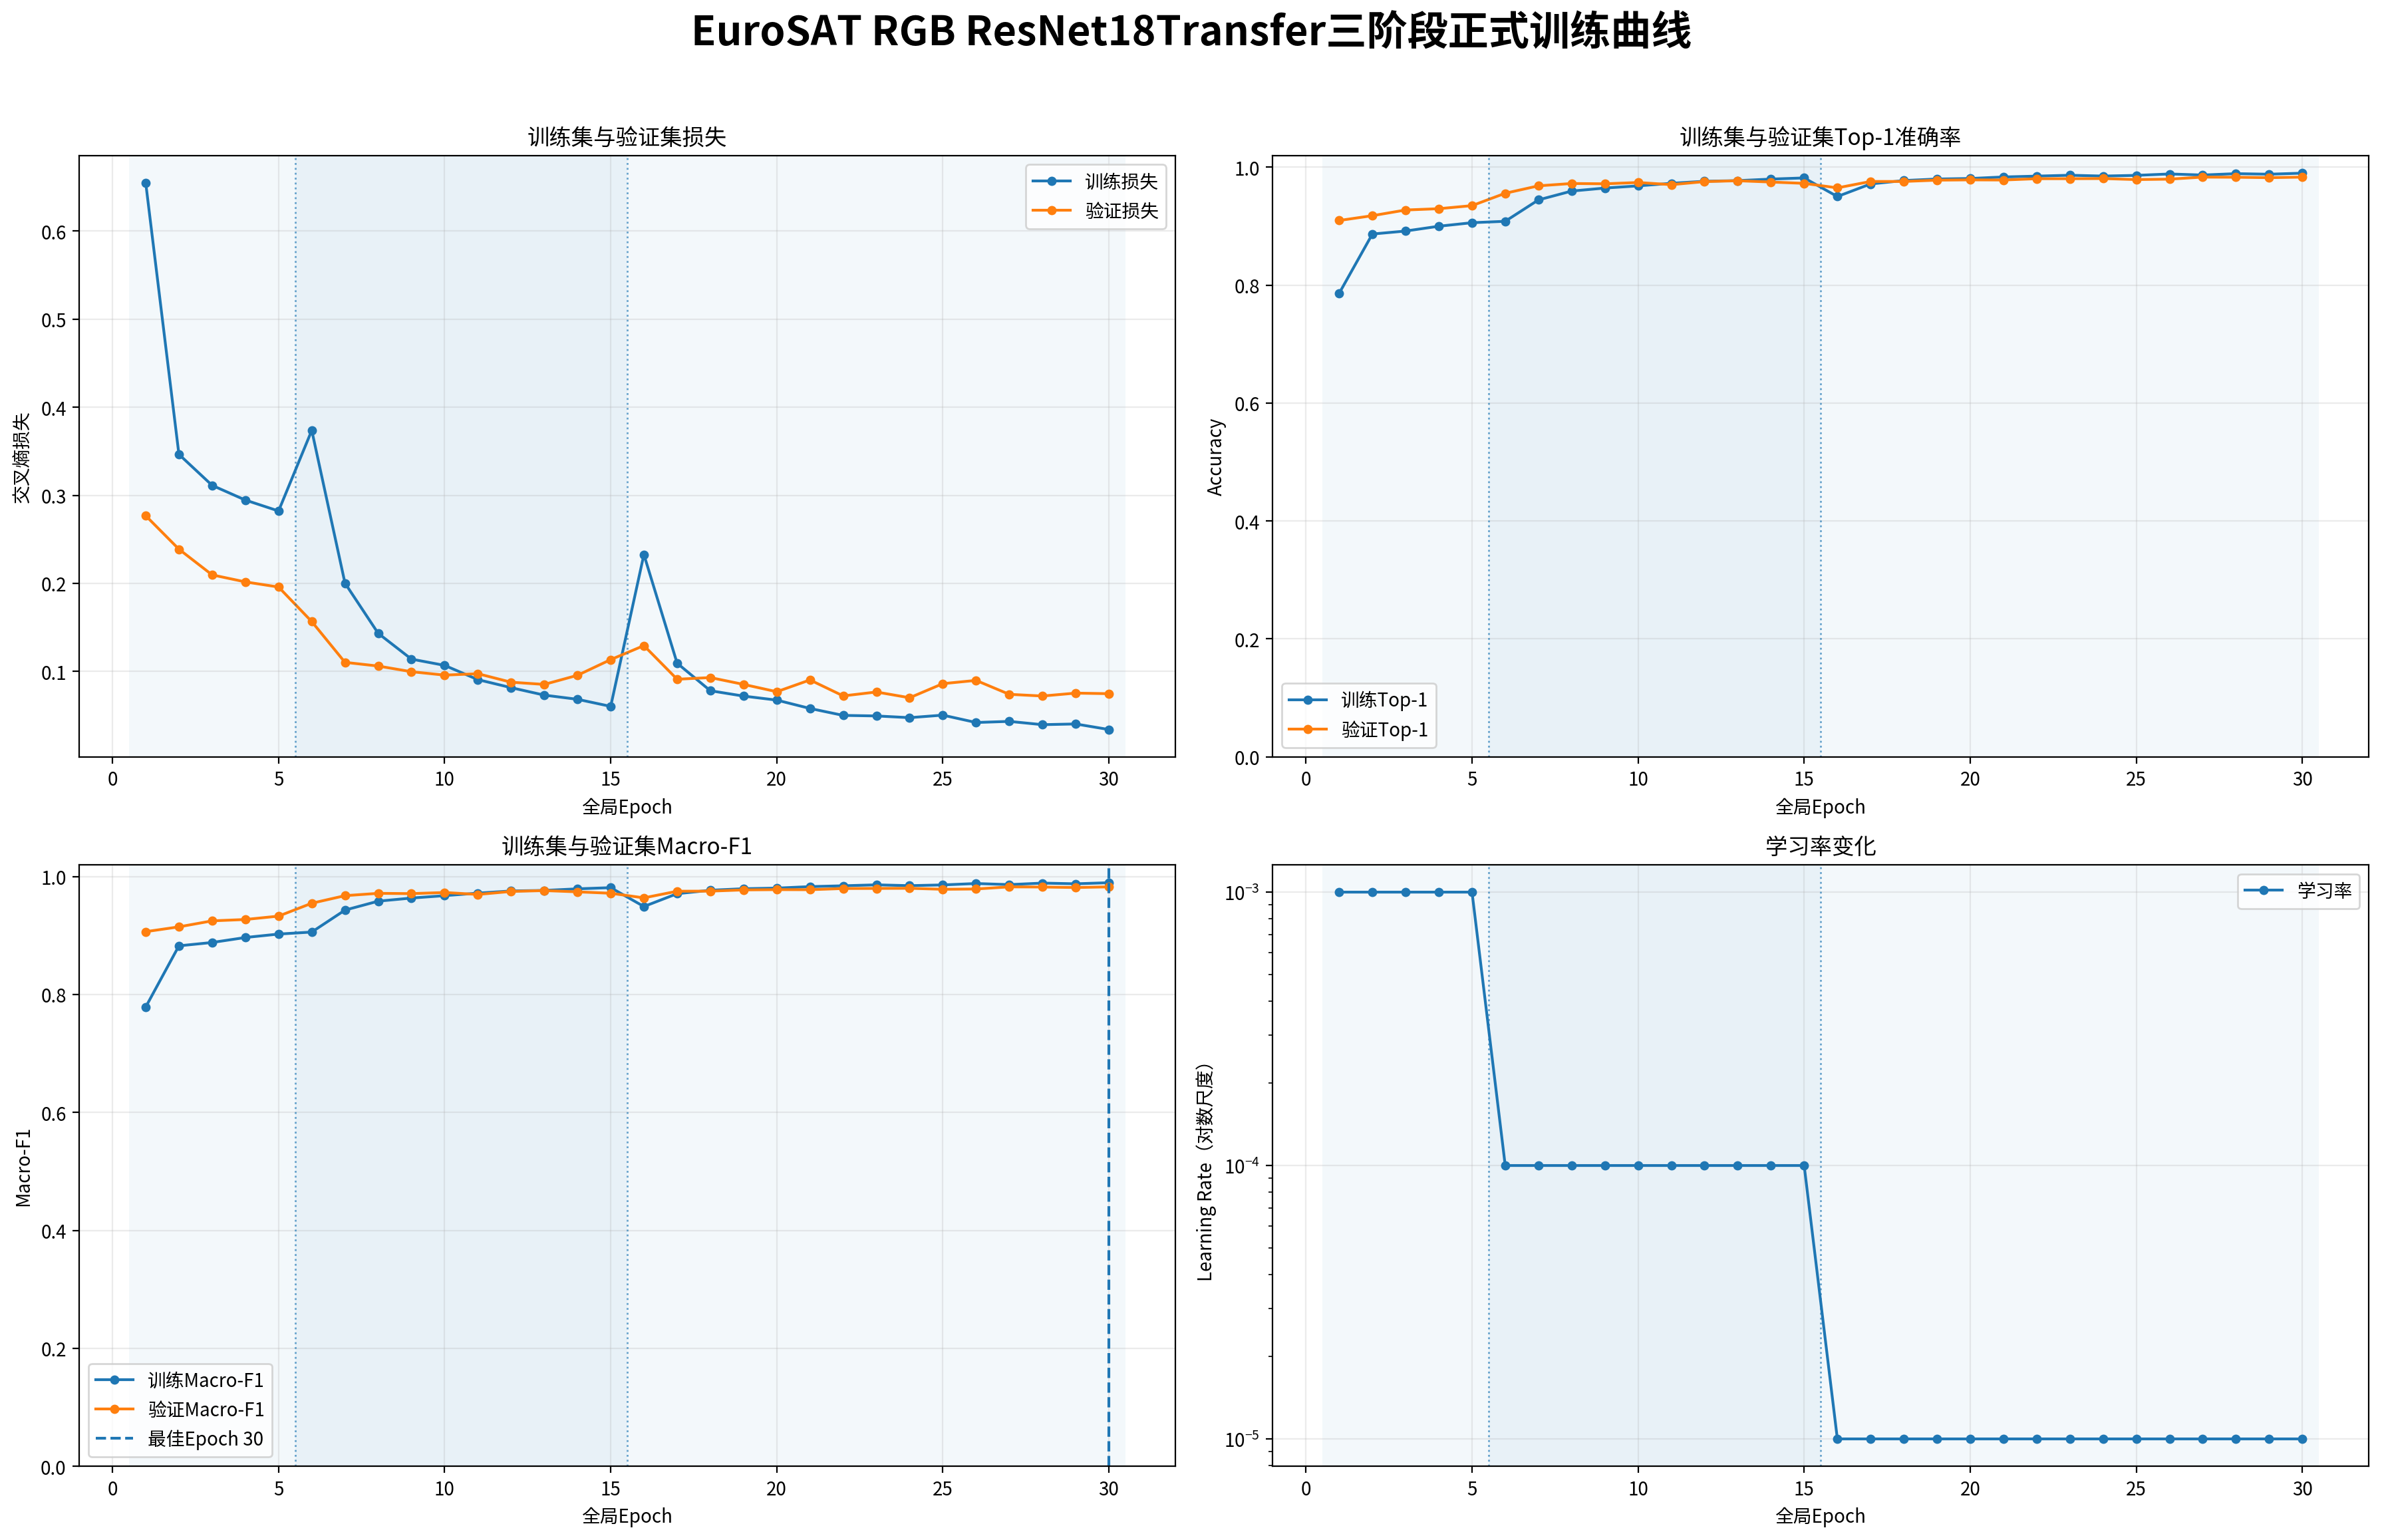


Cell 10执行完成，可以继续运行Cell 11。


In [9]:
# ==========================================
# Cell 10：训练历史曲线与阶段结果汇总
# 非交互式安全版本
# ==========================================

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import (
    Image as IPythonImage,
    display
)


# --------------------------------------------------
# 0. 切换为非交互式绘图后端
# 避免VS Code远程环境卡在widget渲染
# --------------------------------------------------
plt.close(
    "all"
)

plt.switch_backend(
    "Agg"
)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# --------------------------------------------------
# 1. 读取训练历史
# --------------------------------------------------
if not HISTORY_PATH.is_file():
    raise FileNotFoundError(
        f"训练历史不存在：\n"
        f"{HISTORY_PATH}"
    )


history_df = pd.read_csv(
    HISTORY_PATH,
    encoding="utf-8-sig"
)


if len(
    history_df
) == 0:
    raise ValueError(
        "训练历史文件为空。"
    )


required_columns = [
    "global_epoch",
    "phase_key",
    "train_loss",
    "val_loss",
    "train_top1",
    "val_top1",
    "train_macro_f1",
    "val_macro_f1",
    "learning_rate_before"
]


missing_columns = [
    column
    for column in required_columns
    if column not in history_df.columns
]


if missing_columns:
    raise KeyError(
        "训练历史缺少必要字段：\n"
        + "\n".join(
            missing_columns
        )
    )


history_df = (
    history_df
    .sort_values(
        "global_epoch"
    )
    .reset_index(
        drop=True
    )
)


# 直接根据训练历史确定最佳Epoch，
# 不再读取大型模型权重文件
best_row_index = (
    history_df[
        "val_macro_f1"
    ]
    .idxmax()
)

best_history_row = (
    history_df.loc[
        best_row_index
    ]
)

best_epoch = int(
    best_history_row[
        "global_epoch"
    ]
)


print(
    f"训练历史读取成功："
    f"{len(history_df)}轮"
)

print(
    f"最佳Epoch："
    f"{best_epoch}"
)

print(
    f"最佳验证Macro-F1："
    f"{float(best_history_row['val_macro_f1']):.6f}"
)

print(
    f"最佳验证Top-1："
    f"{float(best_history_row['val_top1']):.6f}"
)


# --------------------------------------------------
# 2. 绘制三阶段训练曲线
# --------------------------------------------------
figure, axes = plt.subplots(
    2,
    2,
    figsize=(
        18,
        12
    )
)


epoch_values = history_df[
    "global_epoch"
].to_numpy()


# 训练与验证损失
axes[
    0,
    0
].plot(
    epoch_values,
    history_df[
        "train_loss"
    ],
    marker="o",
    markersize=4,
    label="训练损失"
)

axes[
    0,
    0
].plot(
    epoch_values,
    history_df[
        "val_loss"
    ],
    marker="o",
    markersize=4,
    label="验证损失"
)

axes[
    0,
    0
].set_title(
    "训练集与验证集损失"
)

axes[
    0,
    0
].set_xlabel(
    "全局Epoch"
)

axes[
    0,
    0
].set_ylabel(
    "交叉熵损失"
)

axes[
    0,
    0
].grid(
    alpha=0.25
)

axes[
    0,
    0
].legend()


# 训练与验证Top-1
axes[
    0,
    1
].plot(
    epoch_values,
    history_df[
        "train_top1"
    ],
    marker="o",
    markersize=4,
    label="训练Top-1"
)

axes[
    0,
    1
].plot(
    epoch_values,
    history_df[
        "val_top1"
    ],
    marker="o",
    markersize=4,
    label="验证Top-1"
)

axes[
    0,
    1
].set_title(
    "训练集与验证集Top-1准确率"
)

axes[
    0,
    1
].set_xlabel(
    "全局Epoch"
)

axes[
    0,
    1
].set_ylabel(
    "Accuracy"
)

axes[
    0,
    1
].set_ylim(
    0,
    1.02
)

axes[
    0,
    1
].grid(
    alpha=0.25
)

axes[
    0,
    1
].legend()


# 训练与验证Macro-F1
axes[
    1,
    0
].plot(
    epoch_values,
    history_df[
        "train_macro_f1"
    ],
    marker="o",
    markersize=4,
    label="训练Macro-F1"
)

axes[
    1,
    0
].plot(
    epoch_values,
    history_df[
        "val_macro_f1"
    ],
    marker="o",
    markersize=4,
    label="验证Macro-F1"
)

axes[
    1,
    0
].axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"最佳Epoch "
        f"{best_epoch}"
    )
)

axes[
    1,
    0
].set_title(
    "训练集与验证集Macro-F1"
)

axes[
    1,
    0
].set_xlabel(
    "全局Epoch"
)

axes[
    1,
    0
].set_ylabel(
    "Macro-F1"
)

axes[
    1,
    0
].set_ylim(
    0,
    1.02
)

axes[
    1,
    0
].grid(
    alpha=0.25
)

axes[
    1,
    0
].legend()


# 学习率
axes[
    1,
    1
].plot(
    epoch_values,
    history_df[
        "learning_rate_before"
    ],
    marker="o",
    markersize=4,
    label="学习率"
)

axes[
    1,
    1
].set_yscale(
    "log"
)

axes[
    1,
    1
].set_title(
    "学习率变化"
)

axes[
    1,
    1
].set_xlabel(
    "全局Epoch"
)

axes[
    1,
    1
].set_ylabel(
    "Learning Rate（对数尺度）"
)

axes[
    1,
    1
].grid(
    alpha=0.25
)

axes[
    1,
    1
].legend()


# --------------------------------------------------
# 3. 标注三个训练阶段
# --------------------------------------------------
phase_spans = []

phase_start_epoch = 1


for phase in PHASE_CONFIGS:

    phase_end_epoch = (
        phase_start_epoch
        + int(
            phase[
                "epochs"
            ]
        )
        - 1
    )

    phase_spans.append(
        (
            phase_start_epoch,
            phase_end_epoch,
            phase[
                "short_name"
            ]
        )
    )

    phase_start_epoch = (
        phase_end_epoch
        + 1
    )


for axis in axes.ravel():

    for span_index, (
        span_start,
        span_end,
        span_name
    ) in enumerate(
        phase_spans
    ):

        axis.axvspan(
            span_start - 0.5,
            span_end + 0.5,
            alpha=(
                0.05
                if span_index % 2 == 0
                else 0.10
            )
        )

        if span_index > 0:

            axis.axvline(
                span_start - 0.5,
                linestyle=":",
                linewidth=1,
                alpha=0.65
            )


figure.suptitle(
    "EuroSAT RGB ResNet18Transfer三阶段正式训练曲线",
    fontsize=22,
    fontweight="bold"
)


figure.tight_layout(
    rect=[
        0,
        0.02,
        1,
        0.96
    ]
)


TRAIN_CURVE_PATH = (
    RESULT_DIR
    / "10_ResNet18Transfer三阶段训练曲线.png"
)


figure.savefig(
    TRAIN_CURVE_PATH,
    dpi=200,
    bbox_inches="tight"
)


# 立即关闭Matplotlib图形，
# 防止远程Notebook阻塞
plt.close(
    figure
)


print(
    f"训练曲线已保存：\n"
    f"{TRAIN_CURVE_PATH}"
)


# --------------------------------------------------
# 4. 汇总各阶段最佳结果
# --------------------------------------------------
stage_summary_records = []


for phase in PHASE_CONFIGS:

    phase_history = history_df[
        history_df[
            "phase_key"
        ].astype(
            str
        ) == str(
            phase[
                "phase_key"
            ]
        )
    ].copy()


    if len(
        phase_history
    ) == 0:
        continue


    phase_best_index = (
        phase_history[
            "val_macro_f1"
        ]
        .idxmax()
    )


    phase_best_row = (
        phase_history.loc[
            phase_best_index
        ]
    )


    if (
        "trainable_parameters"
        in phase_history.columns
    ):
        trainable_parameters = int(
            phase_best_row[
                "trainable_parameters"
            ]
        )

    else:
        trainable_parameters = int(
            phase.get(
                "expected_trainable_parameters",
                0
            )
        )


    if (
        "epoch_seconds"
        in phase_history.columns
    ):
        phase_seconds = float(
            phase_history[
                "epoch_seconds"
            ].sum()
        )

    else:
        phase_seconds = np.nan


    if (
        "peak_memory_gb"
        in phase_history.columns
    ):
        peak_memory_gb = float(
            phase_history[
                "peak_memory_gb"
            ].max()
        )

    else:
        peak_memory_gb = np.nan


    stage_summary_records.append(
        {
            "训练阶段": phase[
                "phase_name"
            ],
            "完成轮数": int(
                len(
                    phase_history
                )
            ),
            "可训练参数": trainable_parameters,
            "最佳全局Epoch": int(
                phase_best_row[
                    "global_epoch"
                ]
            ),
            "最佳验证Loss": float(
                phase_best_row[
                    "val_loss"
                ]
            ),
            "最佳验证Top-1": float(
                phase_best_row[
                    "val_top1"
                ]
            ),
            "最佳验证Top-3": float(
                phase_best_row[
                    "val_top3"
                ]
            ),
            "最佳验证Macro-F1": float(
                phase_best_row[
                    "val_macro_f1"
                ]
            ),
            "阶段总耗时_秒": phase_seconds,
            "阶段显存峰值_GB": peak_memory_gb
        }
    )


stage_summary_df = pd.DataFrame(
    stage_summary_records
)


STAGE_SUMMARY_PATH = (
    RESULT_DIR
    / "11_三阶段最佳结果汇总.csv"
)


stage_summary_df.to_csv(
    STAGE_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig"
)


print(
    "\n三阶段最佳结果："
)

print(
    stage_summary_df.to_string(
        index=False
    )
)


print(
    f"\n阶段结果已保存：\n"
    f"{STAGE_SUMMARY_PATH}"
)


# --------------------------------------------------
# 5. 使用普通静态图片显示
# 不调用ipywidgets渲染器
# --------------------------------------------------
display(
    IPythonImage(
        filename=str(
            TRAIN_CURVE_PATH
        )
    )
)


print(
    "\nCell 10执行完成，"
    "可以继续运行Cell 11。"
)

验证损失函数创建完成：
CrossEntropyLoss，label_smoothing=0.0

最佳模型路径：
/root/autodl-tmp/课设/models/resnet18_transfer/resnet18_transfer_best_model.pth
全局最佳模型权重加载完成。
最佳阶段：阶段C：全模型微调
最佳全局Epoch：30



全局最佳模型验证集总体指标：


,最佳训练阶段,最佳全局Epoch,验证集样本数量,验证Loss,验证Top-1,验证Top-3,Macro-Precision,Macro-Recall,Macro-F1,Weighted-F1,平均预测置信度
0,阶段C：全模型微调,30,4050,0.074845,0.98321,0.999753,0.982907,0.982267,0.98256,0.98319,0.994494



全局最佳模型验证集各类别指标：


,类别索引,类别中文名称,类别英文名称,Precision,Recall,F1,Support
0,0,年生作物地,AnnualCrop,0.965217,0.986667,0.975824,450
1,1,永久性作物地,PermanentCrop,0.970430,0.962667,0.966533,375
2,2,森林,Forest,0.995556,0.995556,0.995556,450
3,3,草本植被,HerbaceousVegetation,0.975281,0.964444,0.969832,450
4,4,牧场,Pasture,0.976271,0.960000,0.968067,300
5,5,高速公路,Highway,0.981481,0.989333,0.985392,375
6,6,工业区,Industrial,0.992000,0.992000,0.992000,375
7,7,居民区,Residential,0.993377,1.000000,0.996678,450
8,8,河流,River,0.983914,0.978667,0.981283,375
9,9,海洋与湖泊,SeaLake,0.995546,0.993333,0.994438,450


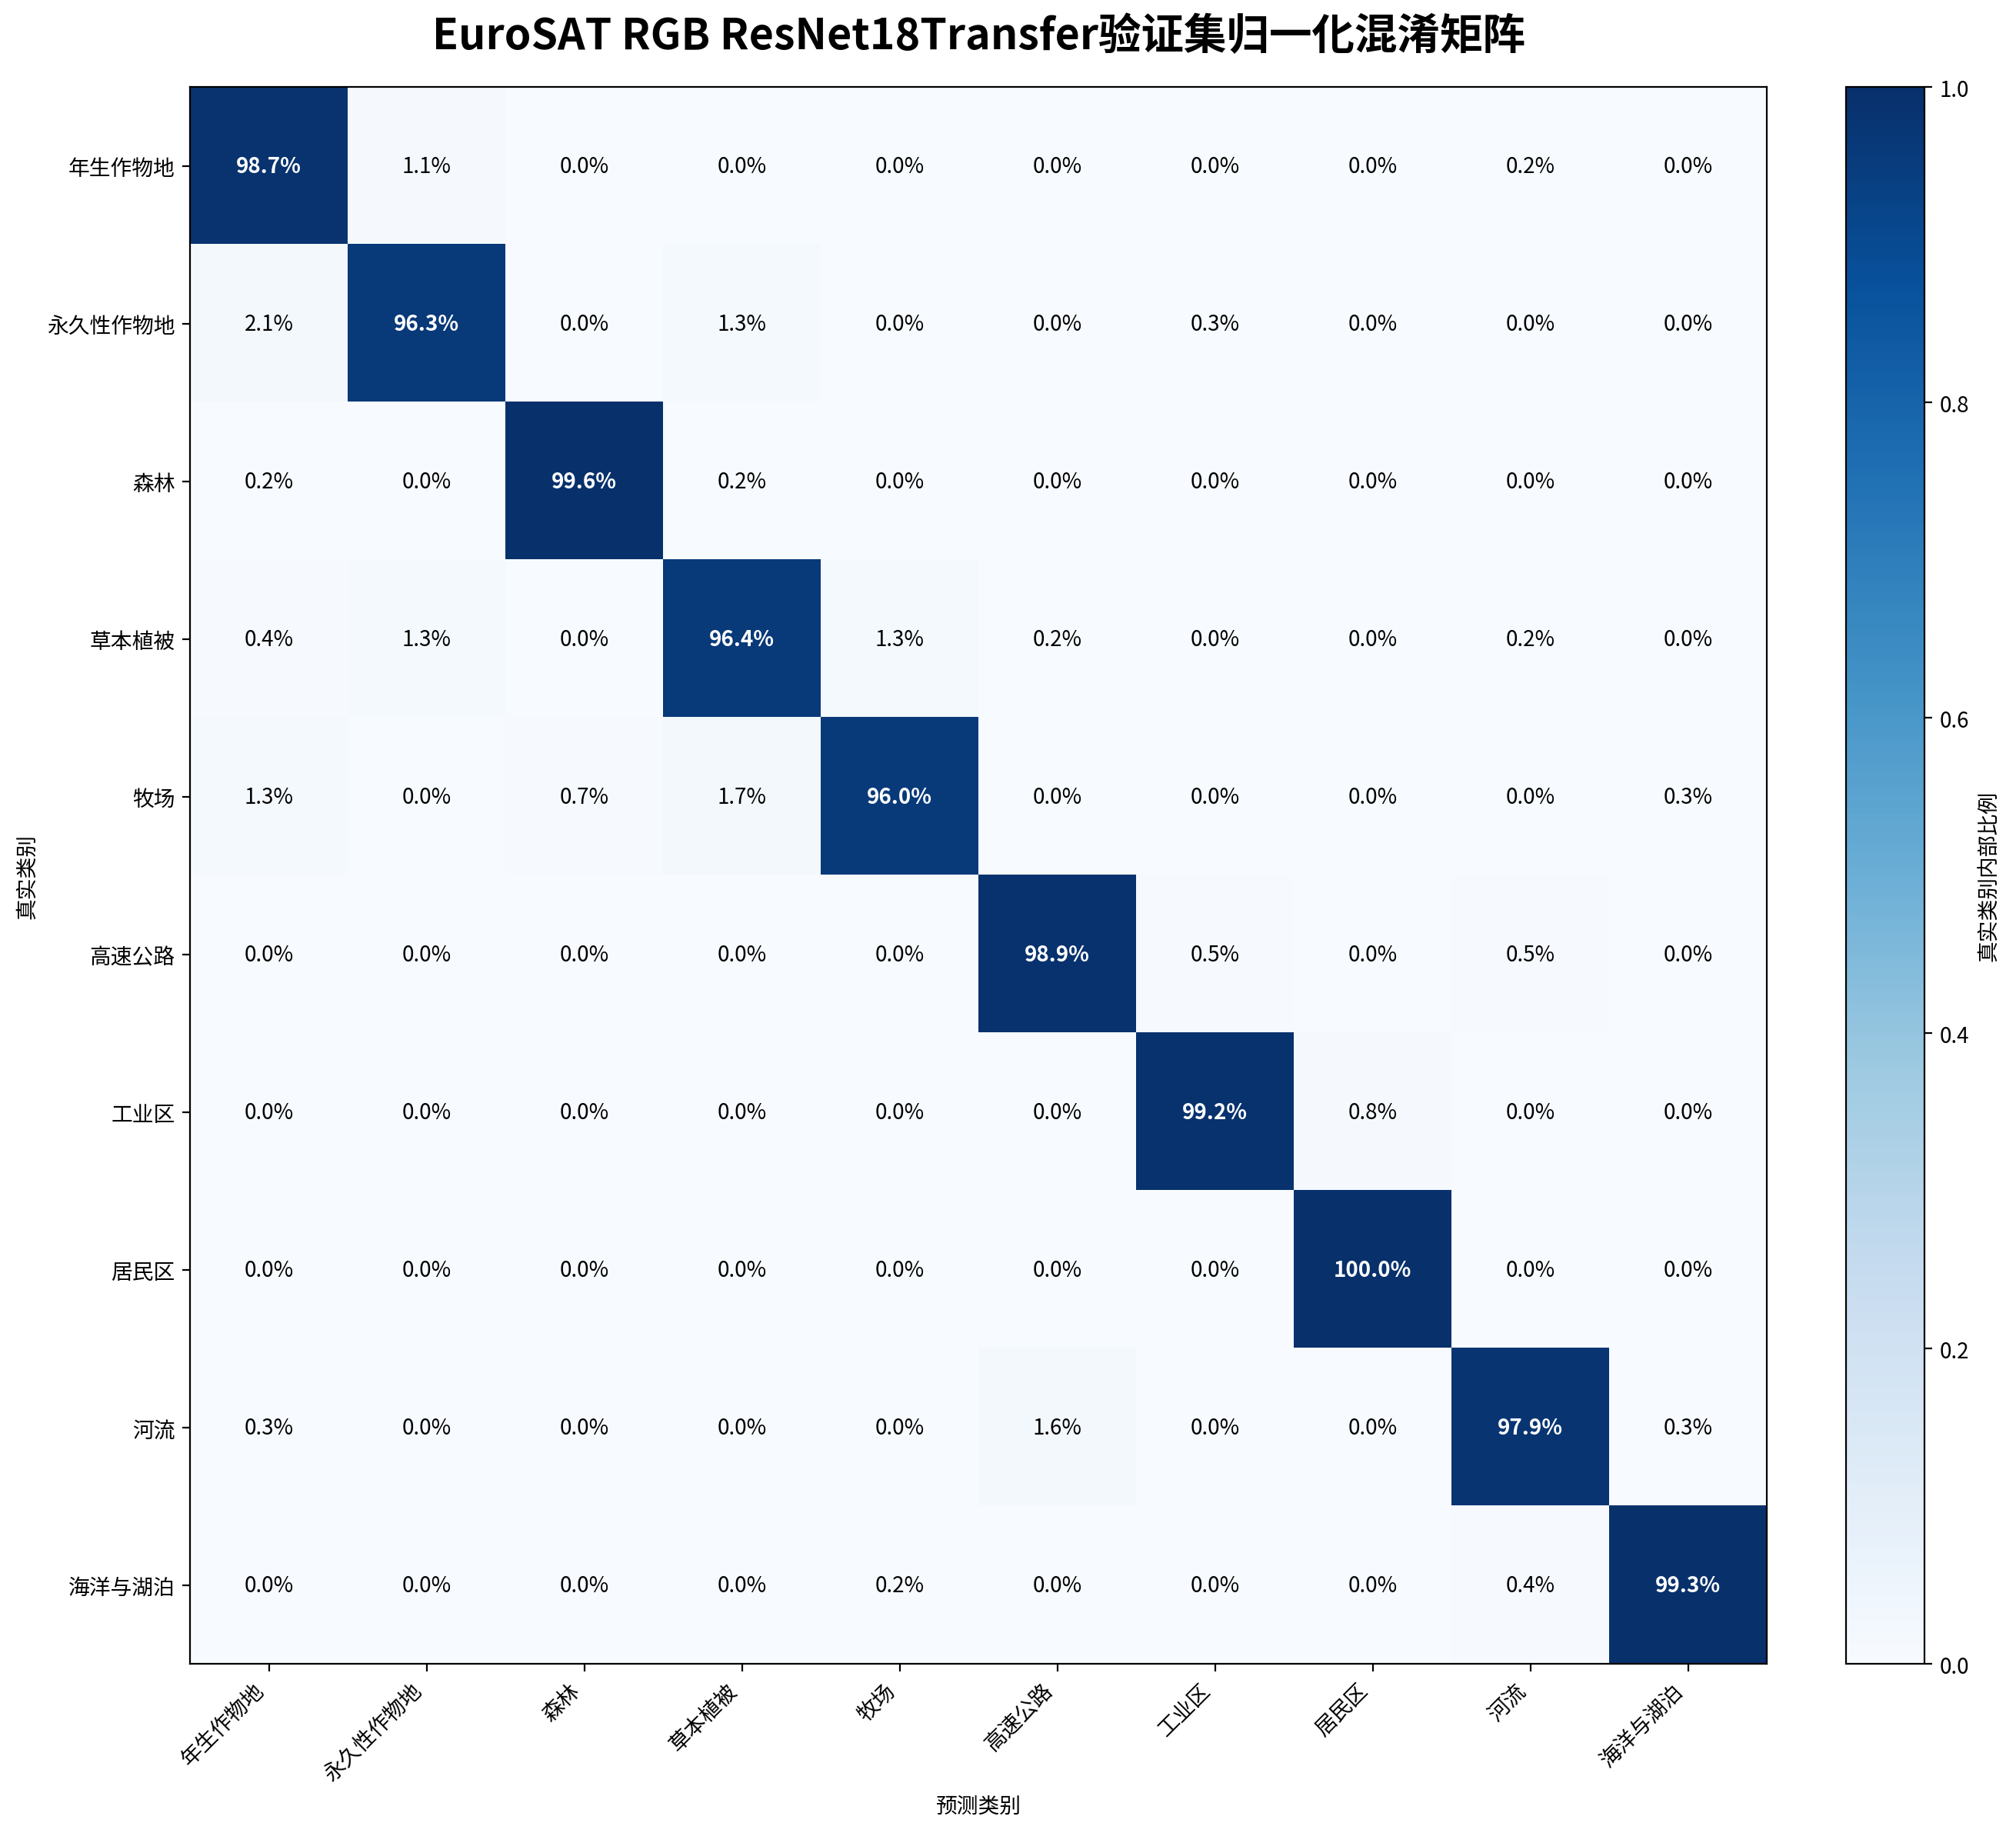


全局最佳模型验证集正式评估完成。
最佳阶段：阶段C：全模型微调
最佳Epoch：30
验证Top-1：98.3210%
验证Top-3：99.9753%
验证Macro-F1：98.2560%

总体指标已保存：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.3_ResNet18Transfer分阶段正式训练/12_全局最佳模型验证集总体指标.csv

各类别指标已保存：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.3_ResNet18Transfer分阶段正式训练/13_全局最佳模型验证集各类别指标.csv

混淆矩阵图片已保存：
/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.3_ResNet18Transfer分阶段正式训练/17_验证集归一化混淆矩阵.png

Cell 11执行完成，可以继续运行Cell 12。


In [10]:
# ==========================================
# Cell 11：加载全局最佳模型并完成验证集正式评估
# 内核重启后独立运行修正版
# ==========================================

import json

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from IPython.display import display


# --------------------------------------------------
# 0. 补充验证所需的损失函数
# 原版criterion在训练Cell 9中定义，
# 跳过Cell 9后需要在此重新创建
# --------------------------------------------------
if "LABEL_SMOOTHING" not in globals():

    LABEL_SMOOTHING = 0.0


criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)


print(
    "验证损失函数创建完成："
)

print(
    f"CrossEntropyLoss，"
    f"label_smoothing={LABEL_SMOOTHING}"
)


# --------------------------------------------------
# 1. 检查关键变量与文件
# --------------------------------------------------
required_variable_names = [
    "model",
    "DEVICE",
    "val_loader",
    "evaluate_model",
    "BEST_MODEL_PATH",
    "RESULT_DIR",
    "NUM_CLASSES",
    "CLASS_NAMES_CN",
    "CLASS_NAMES_EN"
]


missing_variable_names = [
    variable_name
    for variable_name
    in required_variable_names
    if variable_name not in globals()
]


if missing_variable_names:

    raise NameError(
        "当前内核缺少以下必要变量：\n"
        + "\n".join(
            missing_variable_names
        )
        + "\n\n请确认已经运行Cell 2至Cell 8，"
        "但不要运行正式训练Cell 9。"
    )


if not BEST_MODEL_PATH.is_file():

    raise FileNotFoundError(
        "未找到全局最佳模型：\n"
        f"{BEST_MODEL_PATH}"
    )


print(
    f"\n最佳模型路径：\n"
    f"{BEST_MODEL_PATH}"
)


# --------------------------------------------------
# 2. 读取最佳模型检查点
# --------------------------------------------------
best_checkpoint = safe_torch_load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)


if not isinstance(
    best_checkpoint,
    dict
):

    raise TypeError(
        "最佳模型检查点格式异常，"
        "预期为字典格式。"
    )


if "model_state_dict" not in best_checkpoint:

    raise KeyError(
        "最佳模型检查点中不存在"
        "model_state_dict字段。"
    )


model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ],
    strict=True
)


model = model.to(
    DEVICE
)

model.eval()


print(
    "全局最佳模型权重加载完成。"
)

print(
    f"最佳阶段："
    f"{best_checkpoint.get('phase_name', '未记录')}"
)

print(
    f"最佳全局Epoch："
    f"{best_checkpoint.get('best_global_epoch', '未记录')}"
)


# --------------------------------------------------
# 3. 验证集正式评估
# --------------------------------------------------
best_val_result = evaluate_model(
    target_model=model,
    data_loader=val_loader,
    criterion=criterion,
    return_outputs=True
)


# 防止后续修改原结果字典时产生混淆
best_val_result = (
    best_val_result.copy()
)


y_true = best_val_result.pop(
    "y_true"
)

y_pred = best_val_result.pop(
    "y_pred"
)

confidence = best_val_result.pop(
    "confidence"
)

validation_paths = best_val_result.pop(
    "paths"
)


assert len(
    y_true
) == len(
    val_dataset
), (
    "验证结果数量与验证集样本数量不一致。"
)

assert len(
    y_pred
) == len(
    y_true
)

assert len(
    confidence
) == len(
    y_true
)

assert len(
    validation_paths
) == len(
    y_true
)


# --------------------------------------------------
# 4. 总体评价指标
# --------------------------------------------------
best_validation_summary = {
    "最佳训练阶段": (
        best_checkpoint.get(
            "phase_name",
            "未记录"
        )
    ),
    "最佳全局Epoch": int(
        best_checkpoint.get(
            "best_global_epoch",
            0
        )
    ),
    "验证集样本数量": int(
        len(
            y_true
        )
    ),
    "验证Loss": float(
        best_val_result[
            "loss"
        ]
    ),
    "验证Top-1": float(
        best_val_result[
            "top1"
        ]
    ),
    "验证Top-3": float(
        best_val_result[
            "top3"
        ]
    ),
    "Macro-Precision": float(
        best_val_result[
            "macro_precision"
        ]
    ),
    "Macro-Recall": float(
        best_val_result[
            "macro_recall"
        ]
    ),
    "Macro-F1": float(
        best_val_result[
            "macro_f1"
        ]
    ),
    "Weighted-F1": float(
        best_val_result[
            "weighted_f1"
        ]
    ),
    "平均预测置信度": float(
        confidence.mean()
    )
}


best_validation_summary_df = pd.DataFrame(
    [
        best_validation_summary
    ]
)


print(
    "\n全局最佳模型验证集总体指标："
)

display(
    best_validation_summary_df
)


best_validation_summary_csv_path = (
    RESULT_DIR
    / "12_全局最佳模型验证集总体指标.csv"
)


best_validation_summary_json_path = (
    RESULT_DIR
    / "12_全局最佳模型验证集总体指标.json"
)


best_validation_summary_df.to_csv(
    best_validation_summary_csv_path,
    index=False,
    encoding="utf-8-sig"
)


with open(
    best_validation_summary_json_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        best_validation_summary,
        file,
        ensure_ascii=False,
        indent=2
    )


# --------------------------------------------------
# 5. 各类别评价指标
# --------------------------------------------------
(
    per_class_precision,
    per_class_recall,
    per_class_f1,
    per_class_support
) = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=list(
        range(
            NUM_CLASSES
        )
    ),
    zero_division=0
)


per_class_metrics_df = pd.DataFrame({
    "类别索引": list(
        range(
            NUM_CLASSES
        )
    ),
    "类别中文名称": CLASS_NAMES_CN,
    "类别英文名称": CLASS_NAMES_EN,
    "Precision": per_class_precision,
    "Recall": per_class_recall,
    "F1": per_class_f1,
    "Support": (
        per_class_support
        .astype(
            int
        )
    )
})


print(
    "\n全局最佳模型验证集各类别指标："
)

display(
    per_class_metrics_df
)


per_class_metrics_path = (
    RESULT_DIR
    / "13_全局最佳模型验证集各类别指标.csv"
)


per_class_metrics_df.to_csv(
    per_class_metrics_path,
    index=False,
    encoding="utf-8-sig"
)


# --------------------------------------------------
# 6. 保存验证集逐样本预测明细
# --------------------------------------------------
prediction_detail_df = pd.DataFrame({
    "图像路径": validation_paths,
    "真实类别索引": y_true,
    "真实类别中文名称": [
        CLASS_NAMES_CN[
            int(
                class_index
            )
        ]
        for class_index
        in y_true
    ],
    "预测类别索引": y_pred,
    "预测类别中文名称": [
        CLASS_NAMES_CN[
            int(
                class_index
            )
        ]
        for class_index
        in y_pred
    ],
    "预测置信度": confidence,
    "是否预测正确": (
        y_true
        == y_pred
    )
})


prediction_detail_path = (
    RESULT_DIR
    / "14_全局最佳模型验证集预测明细.csv"
)


prediction_detail_df.to_csv(
    prediction_detail_path,
    index=False,
    encoding="utf-8-sig"
)


# --------------------------------------------------
# 7. 计算并保存混淆矩阵
# --------------------------------------------------
confusion_matrix_raw = confusion_matrix(
    y_true,
    y_pred,
    labels=list(
        range(
            NUM_CLASSES
        )
    )
)


row_sums = confusion_matrix_raw.sum(
    axis=1,
    keepdims=True
)


confusion_matrix_normalized = np.divide(
    confusion_matrix_raw,
    row_sums,
    out=np.zeros_like(
        confusion_matrix_raw,
        dtype=np.float64
    ),
    where=(
        row_sums != 0
    )
)


confusion_raw_df = pd.DataFrame(
    confusion_matrix_raw,
    index=CLASS_NAMES_CN,
    columns=CLASS_NAMES_CN
)


confusion_normalized_df = pd.DataFrame(
    confusion_matrix_normalized,
    index=CLASS_NAMES_CN,
    columns=CLASS_NAMES_CN
)


confusion_raw_path = (
    RESULT_DIR
    / "15_验证集原始混淆矩阵.csv"
)


confusion_normalized_path = (
    RESULT_DIR
    / "16_验证集归一化混淆矩阵.csv"
)


confusion_raw_df.to_csv(
    confusion_raw_path,
    encoding="utf-8-sig"
)


confusion_normalized_df.to_csv(
    confusion_normalized_path,
    encoding="utf-8-sig"
)


# --------------------------------------------------
# 8. 非交互式绘制混淆矩阵
# 避免VS Code远程环境再次卡在输出渲染
# --------------------------------------------------
import matplotlib.pyplot as plt

from IPython.display import (
    Image as IPythonImage,
    display as display_image
)


plt.close(
    "all"
)

plt.switch_backend(
    "Agg"
)


figure, axis = plt.subplots(
    figsize=(
        14,
        12
    )
)


image = axis.imshow(
    confusion_matrix_normalized,
    cmap="Blues",
    vmin=0,
    vmax=1
)


colorbar = figure.colorbar(
    image,
    ax=axis,
    fraction=0.046,
    pad=0.04
)


colorbar.set_label(
    "真实类别内部比例"
)


axis.set_xticks(
    list(
        range(
            NUM_CLASSES
        )
    )
)

axis.set_yticks(
    list(
        range(
            NUM_CLASSES
        )
    )
)


axis.set_xticklabels(
    CLASS_NAMES_CN,
    rotation=45,
    ha="right"
)

axis.set_yticklabels(
    CLASS_NAMES_CN
)


axis.set_xlabel(
    "预测类别"
)

axis.set_ylabel(
    "真实类别"
)


axis.set_title(
    "EuroSAT RGB ResNet18Transfer验证集归一化混淆矩阵",
    fontsize=20,
    fontweight="bold",
    pad=18
)


for row_index in range(
    NUM_CLASSES
):

    for column_index in range(
        NUM_CLASSES
    ):

        cell_value = (
            confusion_matrix_normalized[
                row_index,
                column_index
            ]
        )

        text_color = (
            "white"
            if cell_value >= 0.55
            else "black"
        )

        axis.text(
            column_index,
            row_index,
            f"{cell_value:.1%}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=10,
            fontweight=(
                "bold"
                if row_index
                == column_index
                else "normal"
            )
        )


figure.tight_layout()


CONFUSION_MATRIX_PATH = (
    RESULT_DIR
    / "17_验证集归一化混淆矩阵.png"
)


figure.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=200,
    bbox_inches="tight"
)


plt.close(
    figure
)


display_image(
    IPythonImage(
        filename=str(
            CONFUSION_MATRIX_PATH
        )
    )
)


# --------------------------------------------------
# 9. 最终输出
# --------------------------------------------------
print(
    "\n全局最佳模型验证集正式评估完成。"
)

print(
    f"最佳阶段："
    f"{best_validation_summary['最佳训练阶段']}"
)

print(
    f"最佳Epoch："
    f"{best_validation_summary['最佳全局Epoch']}"
)

print(
    f"验证Top-1："
    f"{best_validation_summary['验证Top-1']:.4%}"
)

print(
    f"验证Top-3："
    f"{best_validation_summary['验证Top-3']:.4%}"
)

print(
    f"验证Macro-F1："
    f"{best_validation_summary['Macro-F1']:.4%}"
)

print(
    f"\n总体指标已保存：\n"
    f"{best_validation_summary_csv_path}"
)

print(
    f"\n各类别指标已保存：\n"
    f"{per_class_metrics_path}"
)

print(
    f"\n混淆矩阵图片已保存：\n"
    f"{CONFUSION_MATRIX_PATH}"
)

print(
    "\nCell 11执行完成，可以继续运行Cell 12。"
)

In [11]:
# ==========================================
# Cell 12：阶段性能与最终各类别F1可视化
# ==========================================

if not (
    RESULT_DIR
    / "11_三阶段最佳结果汇总.csv"
).is_file():
    raise FileNotFoundError(
        "未找到三阶段最佳结果汇总。"
    )


stage_summary_df = pd.read_csv(
    RESULT_DIR
    / "11_三阶段最佳结果汇总.csv",
    encoding="utf-8-sig"
)

per_class_metrics_df = pd.read_csv(
    RESULT_DIR
    / "13_全局最佳模型验证集各类别指标.csv",
    encoding="utf-8-sig"
)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(
        18,
        7
    )
)


# --------------------------------------------------
# 1. 三阶段最佳Top-1与Macro-F1
# --------------------------------------------------
stage_positions = np.arange(
    len(
        stage_summary_df
    )
)

bar_width = 0.36

top1_bars = axes[0].bar(
    stage_positions
    - bar_width / 2,
    stage_summary_df[
        "最佳验证Top-1"
    ],
    width=bar_width,
    label="最佳验证Top-1"
)

f1_bars = axes[0].bar(
    stage_positions
    + bar_width / 2,
    stage_summary_df[
        "最佳验证Macro-F1"
    ],
    width=bar_width,
    label="最佳验证Macro-F1"
)

axes[0].set_xticks(
    stage_positions
)

axes[0].set_xticklabels(
    stage_summary_df[
        "训练阶段"
    ],
    rotation=10
)

axes[0].set_ylim(
    0,
    1.02
)

axes[0].set_ylabel(
    "指标值"
)

axes[0].set_title(
    "三阶段最佳验证指标"
)

axes[0].grid(
    axis="y",
    alpha=0.25
)

axes[0].legend()


for bar_group in [
    top1_bars,
    f1_bars
]:
    for bar in bar_group:
        height = bar.get_height()

        axes[0].text(
            bar.get_x()
            + bar.get_width() / 2,
            height + 0.012,
            f"{height:.2%}",
            ha="center",
            va="bottom",
            fontsize=10
        )


# --------------------------------------------------
# 2. 最佳模型各类别F1
# --------------------------------------------------
class_positions = np.arange(
    NUM_CLASSES
)

class_bars = axes[1].bar(
    class_positions,
    per_class_metrics_df[
        "F1"
    ]
)

axes[1].set_xticks(
    class_positions
)

axes[1].set_xticklabels(
    per_class_metrics_df[
        "类别中文名称"
    ],
    rotation=45,
    ha="right"
)

axes[1].set_ylim(
    0,
    1.02
)

axes[1].set_ylabel(
    "F1"
)

axes[1].set_title(
    "全局最佳模型验证集各类别F1"
)

axes[1].grid(
    axis="y",
    alpha=0.25
)


for bar in class_bars:
    height = bar.get_height()

    axes[1].text(
        bar.get_x()
        + bar.get_width() / 2,
        height + 0.012,
        f"{height:.1%}",
        ha="center",
        va="bottom",
        fontsize=9
    )


figure.suptitle(
    "EuroSAT RGB ResNet18Transfer阶段性能与类别识别结果",
    fontsize=20,
    fontweight="bold"
)

figure.tight_layout(
    rect=[
        0,
        0,
        1,
        0.95
    ]
)


STAGE_CLASS_F1_PATH = (
    RESULT_DIR
    / "18_阶段性能与各类别F1对比.png"
)

figure.savefig(
    STAGE_CLASS_F1_PATH,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# 3. 资源使用汇总
# --------------------------------------------------
resource_summary_df = pd.DataFrame(
    {
        "训练阶段": (
            stage_summary_df[
                "训练阶段"
            ]
        ),
        "完成轮数": (
            stage_summary_df[
                "完成轮数"
            ]
        ),
        "可训练参数": (
            stage_summary_df[
                "可训练参数"
            ]
        ),
        "阶段总耗时_分钟": (
            stage_summary_df[
                "阶段总耗时_秒"
            ]
            / 60
        ),
        "阶段显存峰值_GB": (
            stage_summary_df[
                "阶段显存峰值_GB"
            ]
        )
    }
)

display(
    resource_summary_df
)

resource_summary_df.to_csv(
    RESULT_DIR
    / "19_三阶段资源使用汇总.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    f"阶段与类别结果图已保存："
    f"{STAGE_CLASS_F1_PATH}"
)

,训练阶段,完成轮数,可训练参数,阶段总耗时_分钟,阶段显存峰值_GB
0,阶段A：分类头预热,5,5130,2.415434,0.195881
1,阶段B：深层特征微调,10,8398858,4.910279,0.258855
2,阶段C：全模型微调,15,11181642,7.571204,0.625700


阶段与类别结果图已保存：/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.3_ResNet18Transfer分阶段正式训练/18_阶段性能与各类别F1对比.png


In [12]:
# ==========================================
# Cell 13：训练结果总结与文件归档检查
# ==========================================

history_df = pd.read_csv(
    HISTORY_PATH,
    encoding="utf-8-sig"
)

best_validation_summary_df = pd.read_csv(
    RESULT_DIR
    / "12_全局最佳模型验证集总体指标.csv",
    encoding="utf-8-sig"
)

best_row = (
    best_validation_summary_df.iloc[0]
)

total_training_seconds = float(
    history_df[
        "epoch_seconds"
    ].sum()
)

best_model_size_mb = (
    BEST_MODEL_PATH.stat().st_size
    / 1024 ** 2
)

last_checkpoint_size_mb = (
    LAST_CHECKPOINT_PATH.stat().st_size
    / 1024 ** 2
)


final_overview = {
    "模型名称": "ResNet18Transfer",
    "训练方式": (
        "阶段A分类头预热 → "
        "阶段B Layer4微调 → "
        "阶段C全模型微调"
    ),
    "总训练轮数": int(
        len(
            history_df
        )
    ),
    "模型总参数": int(
        TOTAL_PARAMETERS
    ),
    "最佳训练阶段": str(
        best_row[
            "最佳训练阶段"
        ]
    ),
    "最佳全局Epoch": int(
        best_row[
            "最佳全局Epoch"
        ]
    ),
    "最佳验证Loss": float(
        best_row[
            "验证Loss"
        ]
    ),
    "最佳验证Top-1": float(
        best_row[
            "验证Top-1"
        ]
    ),
    "最佳验证Top-3": float(
        best_row[
            "验证Top-3"
        ]
    ),
    "最佳验证Macro-Precision": float(
        best_row[
            "Macro-Precision"
        ]
    ),
    "最佳验证Macro-Recall": float(
        best_row[
            "Macro-Recall"
        ]
    ),
    "最佳验证Macro-F1": float(
        best_row[
            "Macro-F1"
        ]
    ),
    "最佳验证Weighted-F1": float(
        best_row[
            "Weighted-F1"
        ]
    ),
    "累计训练与验证耗时_分钟": float(
        total_training_seconds
        / 60
    ),
    "训练显存峰值_GB": float(
        history_df[
            "peak_memory_gb"
        ].max()
    ),
    "最佳模型文件_MB": float(
        best_model_size_mb
    ),
    "最近检查点文件_MB": float(
        last_checkpoint_size_mb
    ),
    "最佳模型路径": str(
        BEST_MODEL_PATH
    ),
    "最近检查点路径": str(
        LAST_CHECKPOINT_PATH
    ),
    "结果目录": str(
        RESULT_DIR
    )
}


final_overview_df = pd.DataFrame(
    [
        final_overview
    ]
)

display(
    final_overview_df
)

final_overview_df.to_csv(
    RESULT_DIR
    / "20_ResNet18Transfer正式训练结果总览.csv",
    index=False,
    encoding="utf-8-sig"
)

save_json(
    final_overview,
    RESULT_DIR
    / "20_ResNet18Transfer正式训练结果总览.json"
)


summary_text = f"""
EuroSAT RGB ResNet18Transfer分阶段正式训练总结
============================================================

模型名称：ResNet18Transfer
训练策略：阶段A分类头预热 → 阶段B Layer4微调 → 阶段C全模型微调
总训练轮数：{len(history_df)}
模型总参数：{TOTAL_PARAMETERS:,}

最佳训练阶段：{final_overview['最佳训练阶段']}
最佳全局Epoch：{final_overview['最佳全局Epoch']}
最佳验证Loss：{final_overview['最佳验证Loss']:.6f}
最佳验证Top-1：{final_overview['最佳验证Top-1']:.6%}
最佳验证Top-3：{final_overview['最佳验证Top-3']:.6%}
最佳验证Macro-Precision：{final_overview['最佳验证Macro-Precision']:.6%}
最佳验证Macro-Recall：{final_overview['最佳验证Macro-Recall']:.6%}
最佳验证Macro-F1：{final_overview['最佳验证Macro-F1']:.6%}
最佳验证Weighted-F1：{final_overview['最佳验证Weighted-F1']:.6%}

累计训练与验证耗时：{final_overview['累计训练与验证耗时_分钟']:.2f}分钟
训练显存峰值：{final_overview['训练显存峰值_GB']:.2f} GB
最佳模型文件：{final_overview['最佳模型文件_MB']:.2f} MB

最佳模型路径：
{BEST_MODEL_PATH}

最近检查点路径：
{LAST_CHECKPOINT_PATH}

说明：
1. 本节仅使用训练集和验证集；
2. 测试集没有参与模型训练、调参或最佳轮次选择；
3. 下一步应在6.2.4中与BaselineCNN统一比较；
4. 最终模型确定后，再在6.3.1中对测试集进行一次正式评估。
""".strip()


SUMMARY_TEXT_PATH = (
    RESULT_DIR
    / "21_ResNet18Transfer分阶段正式训练总结.txt"
)

with open(
    SUMMARY_TEXT_PATH,
    "w",
    encoding="utf-8"
) as file:
    file.write(
        summary_text
    )


output_file_records = []

for output_path in sorted(
    RESULT_DIR.rglob("*")
):
    if output_path.is_file():
        output_file_records.append(
            {
                "文件名称": output_path.name,
                "相对路径": str(
                    output_path.relative_to(
                        RESULT_DIR
                    )
                ),
                "文件大小_KB": (
                    output_path.stat().st_size
                    / 1024
                )
            }
        )

for output_path in sorted(
    MODEL_DIR.glob(
        "resnet18_transfer*.pth"
    )
):
    if output_path.is_file():
        output_file_records.append(
            {
                "文件名称": output_path.name,
                "相对路径": str(
                    output_path
                ),
                "文件大小_KB": (
                    output_path.stat().st_size
                    / 1024
                )
            }
        )


output_files_df = pd.DataFrame(
    output_file_records
)

display(
    output_files_df
)

output_files_df.to_csv(
    RESULT_DIR
    / "22_本节输出文件清单.csv",
    index=False,
    encoding="utf-8-sig"
)


print(
    summary_text
)

print(
    "\n"
    + "=" * 88
)

print(
    "6.2.3 ResNet18Transfer分阶段正式训练已完成。"
)

print(
    "下一步："
    "6.2.4_候选模型训练结果对比与最终模型确定.ipynb"
)

,模型名称,训练方式,总训练轮数,模型总参数,最佳训练阶段,最佳全局Epoch,最佳验证Loss,最佳验证Top-1,最佳验证Top-3,最佳验证Macro-Precision,最佳验证Macro-Recall,最佳验证Macro-F1,最佳验证Weighted-F1,累计训练与验证耗时_分钟,训练显存峰值_GB,最佳模型文件_MB,最近检查点文件_MB,最佳模型路径,最近检查点路径,结果目录
0,ResNet18Transfer,阶段A分类头预热 → 阶段B Layer4微调 → 阶段C全模型微调,30,11181642,阶段C：全模型微调,30,0.074845,0.98321,0.999753,0.982907,0.982267,0.98256,0.98319,14.896917,0.6257,42.732176,42.748409,/root/autodl-tmp/课设/models/resnet18_transfer/r...,/root/autodl-tmp/课设/models/resnet18_transfer/r...,/root/autodl-tmp/课设/results/06_模型训练与优化/6.2.3_R...


,文件名称,相对路径,文件大小_KB
0,00_ResNet18Transfer正式训练配置.json,00_ResNet18Transfer正式训练配置.json,0.828125
1,01_训练集标准化清单.csv,01_训练集标准化清单.csv,2508.784180
2,02_验证集标准化清单.csv,02_验证集标准化清单.csv,537.790039
3,03_训练验证类别分布.csv,03_训练验证类别分布.csv,0.410156
4,04_DataLoader配置与规模.csv,04_DataLoader配置与规模.csv,0.138672
5,05_ResNet18Transfer模型结构.txt,05_ResNet18Transfer模型结构.txt,4.602539
6,06_三阶段迁移学习配置.csv,06_三阶段迁移学习配置.csv,0.407227
7,07_ResNet18Transfer训练历史.csv,07_ResNet18Transfer训练历史.csv,12.534180
8,08_三阶段训练摘要.json,08_三阶段训练摘要.json,1.203125
9,09_正式训练状态.json,09_正式训练状态.json,0.626953


EuroSAT RGB ResNet18Transfer分阶段正式训练总结

模型名称：ResNet18Transfer
训练策略：阶段A分类头预热 → 阶段B Layer4微调 → 阶段C全模型微调
总训练轮数：30
模型总参数：11,181,642

最佳训练阶段：阶段C：全模型微调
最佳全局Epoch：30
最佳验证Loss：0.074845
最佳验证Top-1：98.320988%
最佳验证Top-3：99.975309%
最佳验证Macro-Precision：98.290740%
最佳验证Macro-Recall：98.226667%
最佳验证Macro-F1：98.256034%
最佳验证Weighted-F1：98.319033%

累计训练与验证耗时：14.90分钟
训练显存峰值：0.63 GB
最佳模型文件：42.73 MB

最佳模型路径：
/root/autodl-tmp/课设/models/resnet18_transfer/resnet18_transfer_best_model.pth

最近检查点路径：
/root/autodl-tmp/课设/models/resnet18_transfer/resnet18_transfer_last_checkpoint.pth

说明：
1. 本节仅使用训练集和验证集；
2. 测试集没有参与模型训练、调参或最佳轮次选择；
3. 下一步应在6.2.4中与BaselineCNN统一比较；
4. 最终模型确定后，再在6.3.1中对测试集进行一次正式评估。

6.2.3 ResNet18Transfer分阶段正式训练已完成。
下一步：6.2.4_候选模型训练结果对比与最终模型确定.ipynb
